# Pre Proccess

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


models_scores_path = "C:\\Users\\matan\\master_thesis\\rl_envs\\procgen\\results\\simple_eval100.csv" #"../../results/models_results.csv"
models_scores = pd.read_csv(models_scores_path)
models_mean_scores = models_scores.groupby('model_index')['total_reward'].mean()
models_mean_dict = {str(k): v for k, v in models_mean_scores.to_dict().items()}

user_question_mapping = {
    'ES_understandable': "The explanations of the agent's paths were clear and easy to understand",
    'ES_overwhelming': "The explanations felt too detailed and overwhelming",
    'ES_feedback_related': "The explanations helped me see how my feedback changed the agent's behavior",
    'ES_helpful': "The visual demonstrations of policy changes helped me understand the differences between agents",
    'ES_improvement': "My feedback helped improve the agent's performance",
    'ES_combined': "Combined score of the explanations' satisfaction",
    "ai:": "How familiar are you with Artificial Intelligence?",
    "AI_1": "I believe AI will improve my life",
    "AI_2": "I believe that AI will improve my work",
    "AI_3": "I think I will use AI technology in the future",
    "AI_4": "I think AI technology is a threat to humans",
    "AI_5": "I think AI technology is positive for humanity",
}

minigrid_models_mean_scores = {6: ('NoRedLH1_0612', 10.87),
                                5: ('AllColorsLH_0617', 9.39),
                                4: ('OnlyBlueLH_0706', 8.84),
                                3: ('OnlyBlueLL_0625', 7.49),
                                2: ('AllColorsLL1_0526', 6.48),
                                1: ('OnlyGreenLL_0429', 1.88)}

minigrid_user_results = pd.read_csv('user_results_for_combined_minigrid_df.csv')
fruitbot_user_results = pd.read_csv('user_results_for_combined_fruitbot_df.csv')

# choices_results = pd.read_csv('choices_final_results.csv')

In [70]:
minigrid_user_results['final_agent'].value_counts()

final_agent
6    87
4    72
5    65
3    28
2    17
1    11
Name: count, dtype: int64

In [71]:
user_results = pd.concat([
    minigrid_user_results.assign(environment='minigrid'),
    fruitbot_user_results.assign(environment='fruitbot')
], ignore_index=True)

user_results.columns

Index(['user_id', 'group', 'trust_the_agent', 'number_of_choices',
       'final_agent_mean_score', 'user_performance', 'age', 'gender',
       'education', 'familiar_with_AI', 'evaluate_final_agent', 'AI_1',
       'ES_understandable', 'AI_2', 'autentication_check', 'AI_3',
       'ES_overwhelming', 'AI_4', 'ES_feedback_related', 'AI_5', 'ES_helpful',
       'group_label', 'mean_good_choice_local', 'mean_good_choice_global',
       'mean_good_choice_demo', 'final_agent', 'environment', 'ES_improvement',
       'mean_agent_rating', 'final_score'],
      dtype='object')

In [72]:
minigrid_choice_results = pd.read_csv('choice_results_for_combined_minigrid_df.csv')

fruitbot_choice_results = pd.read_csv('choice_results_for_combined_fruitbot_df.csv')
fruitbot_choice_results.rename(columns={'demo_prev_score': 'prev_agent_demo_score', 'demo_updated_score': 'update_agent_demo_score'}, inplace=True)
choices_results = pd.concat([
    minigrid_choice_results.assign(environment='minigrid'),
    fruitbot_choice_results.assign(environment='fruitbot')
])
choices_results.columns

Index(['user_id', 'episode_index', 'group', 'trust_the_agent',
       'feedback_correctness', 'prev_agent', 'updated_agent',
       'prev_agent_mean_score', 'update_agent_mean_score',
       'prev_agent_feedback_score', 'updated_agent_feedback_score', 'choice',
       'good_choice_global', 'good_choice_local', 'choice_time',
       'examples_shown', 'feedback_level', 'demonstration_level',
       'good_choice_demo', 'prev_agent_demo_score', 'update_agent_demo_score',
       'improved_from_prev_feedback', 'improved_from_prev_mean', 'group_label',
       'environment', 'feedback_config', 'demonstration_config',
       'feedback_count', 'agent_rating'],
      dtype='object')

In [73]:
user_results['group_label'].value_counts()

group_label
Salient-Contrast    129
Random              126
Control             122
Same                117
Name: count, dtype: int64

In [74]:
choices_results.columns

Index(['user_id', 'episode_index', 'group', 'trust_the_agent',
       'feedback_correctness', 'prev_agent', 'updated_agent',
       'prev_agent_mean_score', 'update_agent_mean_score',
       'prev_agent_feedback_score', 'updated_agent_feedback_score', 'choice',
       'good_choice_global', 'good_choice_local', 'choice_time',
       'examples_shown', 'feedback_level', 'demonstration_level',
       'good_choice_demo', 'prev_agent_demo_score', 'update_agent_demo_score',
       'improved_from_prev_feedback', 'improved_from_prev_mean', 'group_label',
       'environment', 'feedback_config', 'demonstration_config',
       'feedback_count', 'agent_rating'],
      dtype='object')

In [75]:
choices_results['group_label'] = choices_results['group_label'].replace(
    {'Contrast': 'Salient-Contrast'}
)
choices_results['group_label'].value_counts()


group_label
Random              446
Control             423
Salient-Contrast    418
Same                406
Name: count, dtype: int64

# Plotting

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu, f_oneway, kruskal
import itertools, warnings
warnings.filterwarnings("ignore")
%matplotlib inline


In [77]:
# helper functions: plot_barplot, mannwhitneyu_test, anova_test

colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
group_names = ['Control', 'Same', 'Salient-Contrast', 'Random']

def plot_barplot(df, x_col, y_col, hue=None, hue_names=None, x_val_names=None,
                 figsize=(6, 5), estimator=lambda x: np.mean(x) * 100, errorbar=('ci', 95),
                 palette=None, x_label='Group', y_label='%', order=None,
                 bar_label_fmt='%.1f%%', ylim_bottom=0, title=None):
    if order is None:
        order = sorted(list(df[x_col].unique()))
    plt.figure(figsize=figsize)
    ax = sns.barplot(data=df, x=x_col, y=y_col, hue=hue, estimator=estimator,
                     errorbar=errorbar, palette=palette, order=order)
    for c in ax.containers:
        ax.bar_label(c, fmt=bar_label_fmt, label_type='edge', fontsize=13)
    x_val_names = x_val_names or [str(l) for l in order]
    ax.set_xticklabels(x_val_names, rotation=(40 if len(x_val_names[0]) > 15 else 0),
                       ha=('right' if len(x_val_names[0]) > 15 else 'center'), fontsize=13)
    if x_label: plt.xlabel(x_label, fontsize=14)
    if y_label: plt.ylabel(y_label, fontsize=14)
    plt.yticks(fontsize=13)
    if hue:
        handles, labels = ax.get_legend_handles_labels()
        display_labels = [hue_names.get(l, l) for l in labels] if isinstance(hue_names, dict) else hue_names
        print(f"handles: {handles}, labels: {labels}, display_labels: {display_labels}")
        ax.legend(handles=handles, labels=display_labels, fontsize=11, loc='lower right')
    plt.ylim(bottom=ylim_bottom)
    if title:
        plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

def mannwhitneyu_test(df, y_col, x_col, test_type='two-sided'):
    levels = sorted(df[x_col].unique())
    rows = []
    for a, b in itertools.combinations(levels, 2):
        g1, g2 = df[df[x_col]==a][y_col].dropna(), df[df[x_col]==b][y_col].dropna()
        u, p = mannwhitneyu(g1, g2, alternative=test_type)
        rows.append({'group_1': a, 'group_2': b, 'U': u, 'p': round(p, 4)})
    print(pd.DataFrame(rows).to_string(index=False))

def anova_test(df, y_col, x_col):
    groups = [g[y_col].dropna().values for _, g in df.groupby(x_col)]
    f, pf = f_oneway(*groups)
    h, pk = kruskal(*groups)
    print(f"ANOVA F={f:.4f}, p={pf:.4f}  |  Kruskal-Wallis H={h:.4f}, p={pk:.4f}")

In [78]:
# # Map group labels on choices_results
# _gm = {"1":"Same","2":"Similar","3":"Contrast","4":"Random"}
# choices_results['group_label'] = choices_results['group'].astype(str).map(_gm)

# # Did the updated agent improve over prev on the feedback level?
# def _improved_fb(row):
#     try:
#         fc, fl = str(int(row['feedback_config'])), str(int(row['feedback_level']))
#     except:
#         return None
#     ms = models_scores
#     prev = ms[(ms['config_index'].astype(str)==fc)&(ms['start_level'].astype(str)==fl)&(ms['model_index'].astype(str)==str(row['prev_agent']))]['total_reward'].values
#     upd  = ms[(ms['config_index'].astype(str)==fc)&(ms['start_level'].astype(str)==fl)&(ms['model_index'].astype(str)==str(row['updated_agent']))]['total_reward'].values
#     return int(upd[0] > prev[0]) if len(prev) > 0 and len(upd) > 0 else None

# choices_results['improved_from_prev_feedback'] = choices_results.apply(_improved_fb, axis=1)
# choices_results['improved_from_prev_mean'] = choices_results.apply(
#     lambda r: int(models_mean_dict.get(str(r['updated_agent']),0) > models_mean_dict.get(str(r['prev_agent']),0)), axis=1)

# # Final agent mean score
# user_results['final_agent_mean_score'] = user_results['final_agent'].map(lambda x: models_mean_dict.get(str(x)))

print("Ready — choices:", choices_results.shape, "| users:", user_results.shape)

Ready — choices: (1693, 29) | users: (494, 30)


## Correct Choice

In [79]:
user_results.columns

Index(['user_id', 'group', 'trust_the_agent', 'number_of_choices',
       'final_agent_mean_score', 'user_performance', 'age', 'gender',
       'education', 'familiar_with_AI', 'evaluate_final_agent', 'AI_1',
       'ES_understandable', 'AI_2', 'autentication_check', 'AI_3',
       'ES_overwhelming', 'AI_4', 'ES_feedback_related', 'AI_5', 'ES_helpful',
       'group_label', 'mean_good_choice_local', 'mean_good_choice_global',
       'mean_good_choice_demo', 'final_agent', 'environment', 'ES_improvement',
       'mean_agent_rating', 'final_score'],
      dtype='object')

handles: [<matplotlib.patches.Rectangle object at 0x000001D5C04E9360>, <matplotlib.patches.Rectangle object at 0x000001D5C05100D0>, <matplotlib.patches.Rectangle object at 0x000001D5C0510A00>, <matplotlib.patches.Rectangle object at 0x000001D5C0512710>], labels: ['Same', 'Salient-Contrast', 'Control', 'Random'], display_labels: None


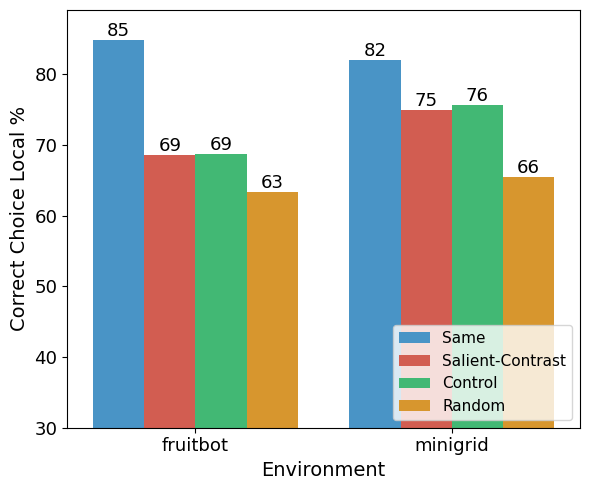

statistic tests for minigrid:
ANOVA F=4.4751, p=0.0044  |  Kruskal-Wallis H=15.2891, p=0.0016
         group_1          group_2      U      p
         Control           Random 3178.5 0.0242
         Control Salient-Contrast 2555.0 0.8784
         Control             Same 1773.5 0.0729
          Random Salient-Contrast 2242.0 0.0381
          Random             Same 1510.0 0.0002
Salient-Contrast             Same 1851.5 0.0522
statistic tests for fruitbot:
ANOVA F=7.1260, p=0.0001  |  Kruskal-Wallis H=21.1580, p=0.0001
         group_1          group_2      U      p
         Control           Random 1482.5 0.2944
         Control Salient-Contrast 1520.0 0.8266
         Control             Same  918.5 0.0005
          Random Salient-Contrast 1271.0 0.4094
          Random             Same  738.0 0.0000
Salient-Contrast             Same  993.5 0.0007


In [80]:
# Plot: Correct Choice (Local) by Group
plot_barplot(user_results, 'environment', 'mean_good_choice_local', hue='group_label', x_label='Environment',
             y_label='Correct Choice Local %', palette=colors_palette, bar_label_fmt='%.0f', ylim_bottom=30, errorbar=None)
            #  order=group_names, x_val_names=group_names)
for env in ['minigrid', 'fruitbot']:
    print(f"statistic tests for {env}:")
    anova_test(user_results[user_results['environment'] == env], 'mean_good_choice_local', 'group_label')
    mannwhitneyu_test(user_results[user_results['environment'] == env], 'mean_good_choice_local', 'group_label', test_type='two-sided')

handles: [<matplotlib.patches.Rectangle object at 0x000001D5BFAB54E0>, <matplotlib.patches.Rectangle object at 0x000001D5BFAB41C0>, <matplotlib.patches.Rectangle object at 0x000001D5C6359900>, <matplotlib.patches.Rectangle object at 0x000001D5C6359150>], labels: ['Same', 'Salient-Contrast', 'Control', 'Random'], display_labels: None


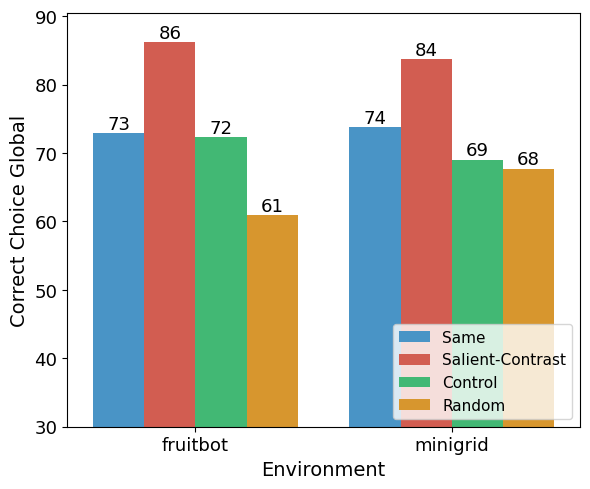

statistic tests for minigrid:
         group_1          group_2      U      p
         Control           Random 2620.5 0.9968
         Control Salient-Contrast 1533.5 0.0000
         Control             Same 1795.5 0.1067
          Random Salient-Contrast 1740.5 0.0000
          Random             Same 2017.5 0.1396
Salient-Contrast             Same 2823.5 0.0090
statistic tests for fruitbot:
         group_1          group_2      U      p
         Control           Random 1758.5 0.0037
         Control Salient-Contrast  818.0 0.0000
         Control             Same 1490.0 0.8415
          Random Salient-Contrast  567.5 0.0000
          Random             Same  999.5 0.0146
Salient-Contrast             Same 2095.0 0.0006


In [128]:
# Plot: Correct Choice (Generalized) by Group
plot_barplot(user_results, 'environment', 'mean_good_choice_global', hue='group_label', errorbar=None, x_label='Environment',
                          y_label='Correct Choice Global', palette=colors_palette, bar_label_fmt='%.0f', ylim_bottom=30)
for env in ['minigrid', 'fruitbot']:
    print(f"statistic tests for {env}:")
    mannwhitneyu_test(user_results[user_results['environment'] == env], 'mean_good_choice_global', 'group_label')

handles: [<matplotlib.patches.Rectangle object at 0x000001D5CA150490>, <matplotlib.patches.Rectangle object at 0x000001D5CA153E20>, <matplotlib.patches.Rectangle object at 0x000001D5CA16DBD0>], labels: ['Same', 'Salient-Contrast', 'Random'], display_labels: None


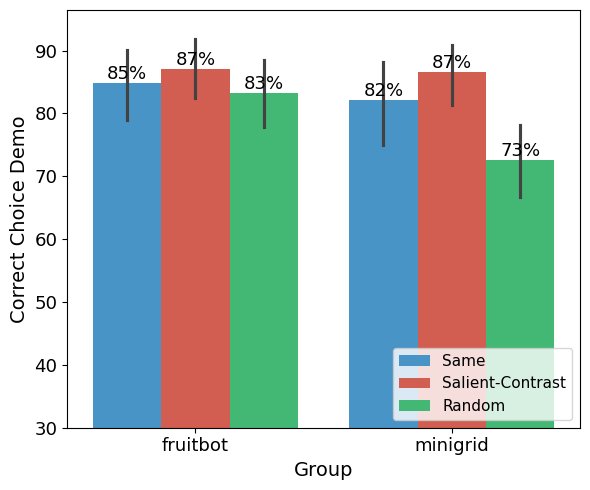

ANOVA F=6.3391, p=0.0020  |  Kruskal-Wallis H=13.7943, p=0.0010
         group_1          group_2      U      p
          Random Salient-Contrast 6183.0 0.0003
          Random             Same 6068.5 0.0105
Salient-Contrast             Same 7918.0 0.4485


In [82]:
# Plot: Correct Choice (demo) by Group
plot_df = user_results[user_results['group_label'] != 'Control']
plot_barplot(plot_df, 'environment', 'mean_good_choice_demo', hue='group_label', 
                          y_label='Correct Choice Demo', palette=colors_palette, bar_label_fmt='%.0f%%', ylim_bottom=30)
anova_test(plot_df, 'mean_good_choice_demo', 'group_label')
mannwhitneyu_test(plot_df, 'mean_good_choice_demo', 'group_label')

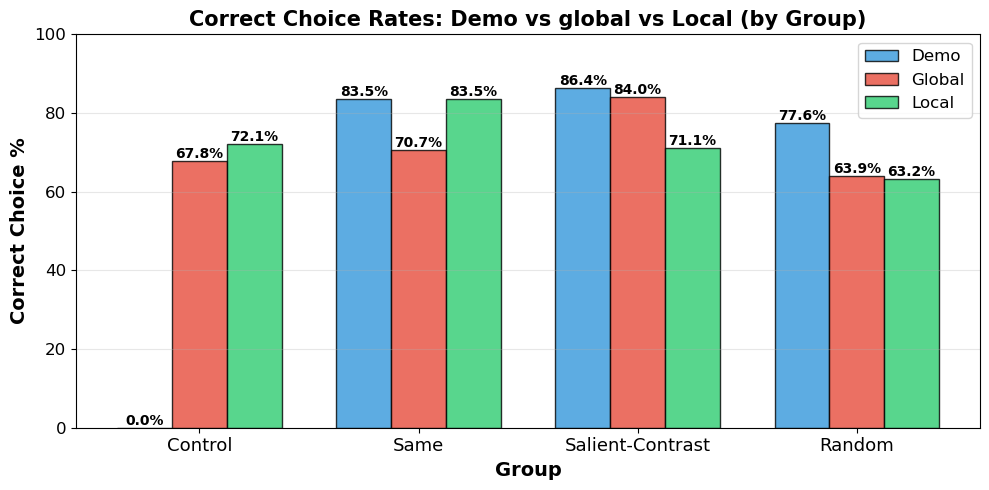


CORRECT CHOICE RATES BY GROUP (%)
           Group  Demo  Global  Local
         Control  0.00   67.85  72.10
            Same 83.50   70.69  83.50
Salient-Contrast 86.36   83.97  71.05
          Random 77.58   63.90  63.23


In [83]:
# Grouped bar plot: Demo, Global, and Local correct choice percentages by group

choice_metrics_data = []
for group in group_names:
    df_group = choices_results[choices_results['group_label'] == group]
    choice_metrics_data.append({
        'Group': group,
        'Demo': df_group['good_choice_demo'].mean() * 100,
        'Global': df_group['good_choice_global'].mean() * 100,
        'Local': df_group['good_choice_local'].mean() * 100
    })

df_metrics = pd.DataFrame(choice_metrics_data)

# Reshape for grouped bar plot
df_melted = df_metrics.melt(id_vars='Group', var_name='Choice Type', value_name='Percentage')

# Create grouped bar plot
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(group_names))
width = 0.25

demo_vals = df_metrics['Demo'].values
global_vals = df_metrics['Global'].values
local_vals = df_metrics['Local'].values

bars1 = ax.bar(x - width, demo_vals, width, label='Demo', color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x, global_vals, width, label='Global', color='#e74c3c', alpha=0.8, edgecolor='black')
bars3 = ax.bar(x + width, local_vals, width, label='Local', color='#2ecc71', alpha=0.8, edgecolor='black')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Group', fontsize=14, fontweight='bold')
ax.set_ylabel('Correct Choice %', fontsize=14, fontweight='bold')
ax.set_title('Correct Choice Rates: Demo vs global vs Local (by Group)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(group_names, fontsize=13)
ax.legend(fontsize=12, loc='upper right')
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*70)
print("CORRECT CHOICE RATES BY GROUP (%)")
print("="*70)
print(df_metrics.to_string(index=False, float_format='%.2f'))


## Correct Choice seperated by improve dir

In [84]:
choices_results.columns

Index(['user_id', 'episode_index', 'group', 'trust_the_agent',
       'feedback_correctness', 'prev_agent', 'updated_agent',
       'prev_agent_mean_score', 'update_agent_mean_score',
       'prev_agent_feedback_score', 'updated_agent_feedback_score', 'choice',
       'good_choice_global', 'good_choice_local', 'choice_time',
       'examples_shown', 'feedback_level', 'demonstration_level',
       'good_choice_demo', 'prev_agent_demo_score', 'update_agent_demo_score',
       'improved_from_prev_feedback', 'improved_from_prev_mean', 'group_label',
       'environment', 'feedback_config', 'demonstration_config',
       'feedback_count', 'agent_rating'],
      dtype='object')

In [85]:
choices_results['environment'].value_counts()

environment
minigrid    916
fruitbot    777
Name: count, dtype: int64

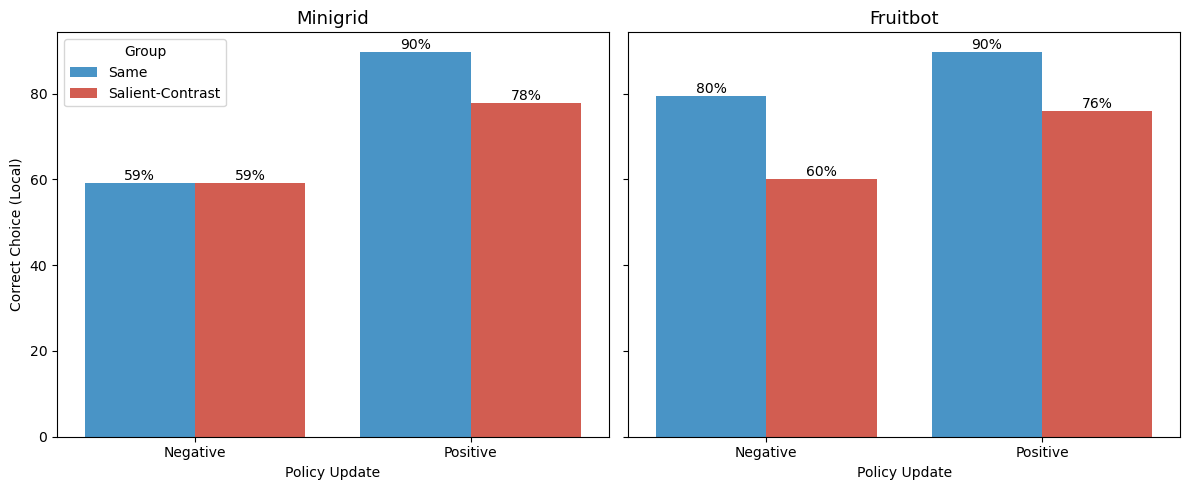

--- Statistical tests for minigrid ---
--- Positive updates ---
         group_1 group_2       U      p
Salient-Contrast    Same 10726.5 0.0042
--- Negative updates ---
         group_1 group_2      U   p
Salient-Contrast    Same 1458.0 1.0
--- Statistical tests for fruitbot ---
--- Positive updates ---
         group_1 group_2      U      p
Salient-Contrast    Same 5445.0 0.0058
--- Negative updates ---
         group_1 group_2      U      p
Salient-Contrast    Same 3186.0 0.0047


In [86]:
# Plot: Correct Choice (Local) by Update Direction — Same vs Contrast
envs = ['minigrid', 'fruitbot']
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, env in zip(axes, envs):
    env_df = choices_results[
        (choices_results['group_label'].isin(['Same', 'Salient-Contrast'])) &
        (choices_results['environment'] == env)
    ].copy()

    sns.barplot(
        data=env_df,
        x='improved_from_prev_feedback',
        y='good_choice_local',
        hue='group_label',
        estimator=lambda x: np.mean(x) * 100,
        errorbar=None, #('ci', 95),
        order=[0, 1],
        hue_order=['Same', 'Salient-Contrast'],
        palette=['#3498db', '#e74c3c'],
        ax=ax
    )

    for c in ax.containers:
        ax.bar_label(c, fmt='%.0f%%', label_type='edge', fontsize=10)

    ax.set_title(env.capitalize(), fontsize=13)
    ax.set_xlabel('Policy Update')
    ax.set_ylabel('Correct Choice (Local)' if ax is axes[0] else '')
    ax.set_xticklabels(['Negative', 'Positive'])

    if ax is not axes[0]:
        ax.legend_.remove()

axes[0].legend(title='Group', fontsize=10)
plt.tight_layout()
plt.show()

# Keep plot_df for statistical tests below (seperate to each environment)
for env in ['minigrid', 'fruitbot']:
    plot_df = choices_results[
        (choices_results['group_label'].isin(['Same', 'Salient-Contrast'])) &
        (choices_results['environment'] == env)
    ].copy()
    print(f"--- Statistical tests for {env} ---")
    print("--- Positive updates ---")
    mannwhitneyu_test(plot_df[plot_df['improved_from_prev_feedback']==1], 'good_choice_local', 'group_label')
    print("--- Negative updates ---")
    mannwhitneyu_test(plot_df[plot_df['improved_from_prev_feedback']==0], 'good_choice_local', 'group_label')

In [87]:
choices_results.groupby(['group_label', 'improved_from_prev_feedback'])['good_choice_local'].mean()

group_label       improved_from_prev_feedback
Control           0                              0.132353
                  1                              1.000000
Random            0                              0.517483
                  1                              0.686469
Salient-Contrast  0                              0.597222
                  1                              0.770073
Same              0                              0.718310
                  1                              0.897727
Name: good_choice_local, dtype: float64

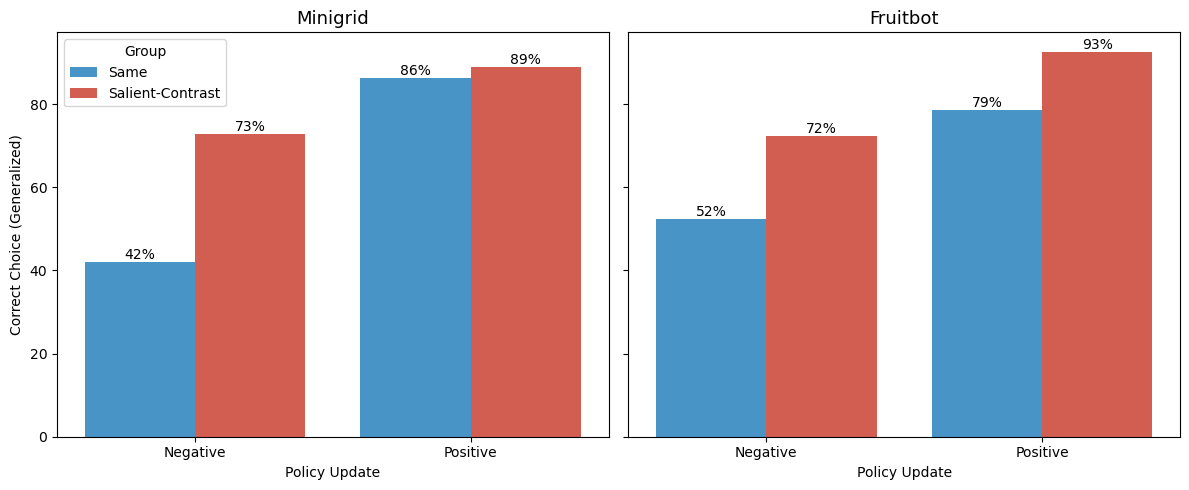

--- Statistical tests for minigrid ---
--- Positive updates ---
         group_1 group_2      U      p
Salient-Contrast    Same 9669.0 0.5395
--- Negative updates ---
         group_1 group_2      U      p
Salient-Contrast    Same 3472.0 0.0002
--- Statistical tests for fruitbot ---
--- Positive updates ---
         group_1 group_2      U      p
Salient-Contrast    Same 9740.0 0.0015
--- Negative updates ---
         group_1 group_2      U      p
Salient-Contrast    Same 2965.5 0.0143


In [129]:
# # Plot: Correct Choice (Generalized) by Update Direction — Same vs Contrast
# plot_df = choices_results[choices_results['group_label'].isin(['Same', 'Salient-Contrast'])].copy()
# for env in ['minigrid', 'fruitbot']:
    # env_df = plot_df[plot_df['environment'] == env]
    # plot_barplot(env_df, 'improved_from_prev_mean', 'good_choice_global', hue='group_label',
    #              y_label=f'Correct Choice (Generalized) % - {env.capitalize()}', x_label='Policy Update',
    #              x_val_names=['Negative', 'Positive'], palette=['#f39c12', '#e74c3c', '#3498db', '#2ecc71'])
# plot_barplot(plot_df, 'improved_from_prev_mean', 'good_choice_global',
#              y_label='Correct Choice (Generalized) %', x_label='Policy Update',
#              x_val_names=['Negative', 'Positive'], hue='group_label',
#              palette=['#f39c12', '#e74c3c', '#3498db', '#2ecc71'])
# print("--- Positive updates ---")
# mannwhitneyu_test(plot_df[plot_df['improved_from_prev_mean']==1], 'good_choice_global', 'group_label')
# print("--- Negative updates ---")
# mannwhitneyu_test(plot_df[plot_df['improved_from_prev_mean']==0], 'good_choice_global', 'group_label')

# Plot: Correct Choice (Local) by Update Direction — Same vs Contrast
envs = ['minigrid', 'fruitbot']
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, env in zip(axes, envs):
    env_df = choices_results[
        (choices_results['group_label'].isin(['Same', 'Salient-Contrast'])) &
        (choices_results['environment'] == env)
    ].copy()

    sns.barplot(
        data=env_df,
        x='improved_from_prev_mean',
        y='good_choice_global',
        hue='group_label',
        estimator=lambda x: np.mean(x) * 100,
        errorbar=None, #('ci', 95),
        order=[0, 1],
        hue_order=['Same', 'Salient-Contrast'],
        palette=['#3498db', '#e74c3c'],
        ax=ax
    )

    for c in ax.containers:
        ax.bar_label(c, fmt='%.0f%%', label_type='edge', fontsize=10)

    ax.set_title(env.capitalize(), fontsize=13)
    ax.set_xlabel('Policy Update')
    ax.set_ylabel('Correct Choice (Generalized)' if ax is axes[0] else '')
    ax.set_xticklabels(['Negative', 'Positive'])

    if ax is not axes[0]:
        ax.legend_.remove()

axes[0].legend(title='Group', fontsize=10)
plt.tight_layout()
plt.show()


for env in ['minigrid', 'fruitbot']:
    plot_df = choices_results[(choices_results['group_label'].isin(['Same', 'Salient-Contrast'])) & (choices_results['environment'] == env) ].copy()
    print(f"--- Statistical tests for {env} ---")
    print("--- Positive updates ---")
    mannwhitneyu_test(plot_df[plot_df['improved_from_prev_mean']==1], 'good_choice_global', 'group_label')
    print("--- Negative updates ---")
    mannwhitneyu_test(plot_df[plot_df['improved_from_prev_mean']==0], 'good_choice_global', 'group_label')

## Agent Rating

In [89]:
user_results.columns

Index(['user_id', 'group', 'trust_the_agent', 'number_of_choices',
       'final_agent_mean_score', 'user_performance', 'age', 'gender',
       'education', 'familiar_with_AI', 'evaluate_final_agent', 'AI_1',
       'ES_understandable', 'AI_2', 'autentication_check', 'AI_3',
       'ES_overwhelming', 'AI_4', 'ES_feedback_related', 'AI_5', 'ES_helpful',
       'group_label', 'mean_good_choice_local', 'mean_good_choice_global',
       'mean_good_choice_demo', 'final_agent', 'environment', 'ES_improvement',
       'mean_agent_rating', 'final_score'],
      dtype='object')

handles: [<matplotlib.patches.Rectangle object at 0x000001D5CA3FF220>, <matplotlib.patches.Rectangle object at 0x000001D5CA3FF6A0>, <matplotlib.patches.Rectangle object at 0x000001D5CA421D20>, <matplotlib.patches.Rectangle object at 0x000001D5CA422890>], labels: ['Same', 'Salient-Contrast', 'Control', 'Random'], display_labels: None


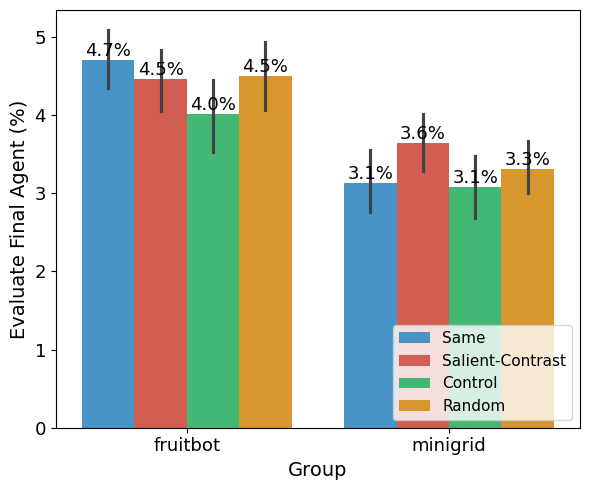

In [90]:
# Plot: Evaluate Final Agent by Group
plot_barplot(
    user_results,
    'environment',
    'evaluate_final_agent',
    hue='group_label',
    estimator='mean',
    y_label='Evaluate Final Agent (%)',
    palette=colors_palette,
    bar_label_fmt='%.1f%%'
 )

handles: [<matplotlib.patches.Rectangle object at 0x000001D5C7177730>, <matplotlib.patches.Rectangle object at 0x000001D5C6926140>], labels: ['Assessment-Loop', 'Control'], display_labels: None


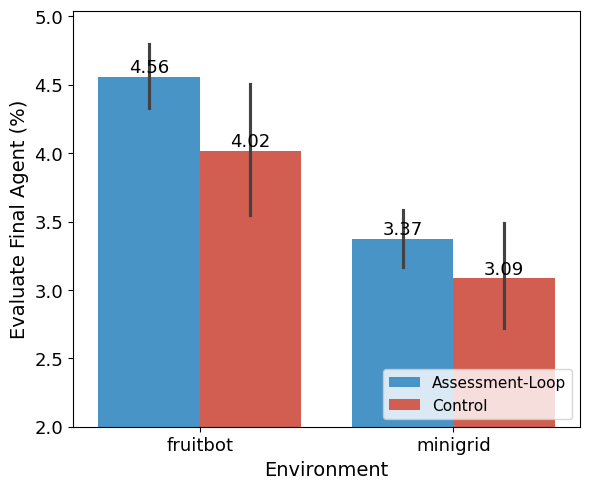

statistic tests for minigrid on evaluate_final_agent:
        group_1 group_2      U      p
Assessment-Loop Control 8161.5 0.0606
statistic tests for fruitbot on evaluate_final_agent:
        group_1 group_2      U      p
Assessment-Loop Control 4997.0 0.0284


In [144]:
# Plot: user Evaluation of Final Agent Control vs Assessment-Loop

plot_df = user_results.copy()
plot_df['group_binary'] = np.where(plot_df['group_label'].isin(['Control']), 'Control', 'Assessment-Loop')

plot_barplot(
    plot_df,
    'environment',
    'evaluate_final_agent',
    hue='group_binary',
    estimator='mean',
    y_label='Evaluate Final Agent (%)',
    x_label='Environment',
    palette=['#3498db', '#e74c3c'],
    bar_label_fmt='%.2f',
    ylim_bottom=2
 )

for env in ['minigrid', 'fruitbot']:
    print(f"statistic tests for {env} on evaluate_final_agent:")
    mannwhitneyu_test(plot_df[plot_df['environment'] == env], 'evaluate_final_agent', 'group_binary', test_type='greater')

In [92]:
user_question_mapping

{'ES_understandable': "The explanations of the agent's paths were clear and easy to understand",
 'ES_overwhelming': 'The explanations felt too detailed and overwhelming',
 'ES_feedback_related': "The explanations helped me see how my feedback changed the agent's behavior",
 'ES_helpful': 'The visual demonstrations of policy changes helped me understand the differences between agents',
 'ES_improvement': "My feedback helped improve the agent's performance",
 'ES_combined': "Combined score of the explanations' satisfaction",
 'ai:': 'How familiar are you with Artificial Intelligence?',
 'AI_1': 'I believe AI will improve my life',
 'AI_2': 'I believe that AI will improve my work',
 'AI_3': 'I think I will use AI technology in the future',
 'AI_4': 'I think AI technology is a threat to humans',
 'AI_5': 'I think AI technology is positive for humanity'}

In [93]:
user_results['ES_combined'] = (user_results['ES_understandable'] + user_results['ES_helpful']+ #  + user_results['ES_improvement']
                                user_results['ES_feedback_related'] + (7 - user_results['ES_overwhelming'])) /4  
                                
user_results.columns

Index(['user_id', 'group', 'trust_the_agent', 'number_of_choices',
       'final_agent_mean_score', 'user_performance', 'age', 'gender',
       'education', 'familiar_with_AI', 'evaluate_final_agent', 'AI_1',
       'ES_understandable', 'AI_2', 'autentication_check', 'AI_3',
       'ES_overwhelming', 'AI_4', 'ES_feedback_related', 'AI_5', 'ES_helpful',
       'group_label', 'mean_good_choice_local', 'mean_good_choice_global',
       'mean_good_choice_demo', 'final_agent', 'environment', 'ES_improvement',
       'mean_agent_rating', 'final_score', 'ES_combined'],
      dtype='object')

The explanations helped me see how my feedback changed the agent's behavior
handles: [<matplotlib.patches.Rectangle object at 0x000001D5C7431990>, <matplotlib.patches.Rectangle object at 0x000001D5C7433610>, <matplotlib.patches.Rectangle object at 0x000001D5C64BE1A0>], labels: ['Same', 'Salient-Contrast', 'Random'], display_labels: None


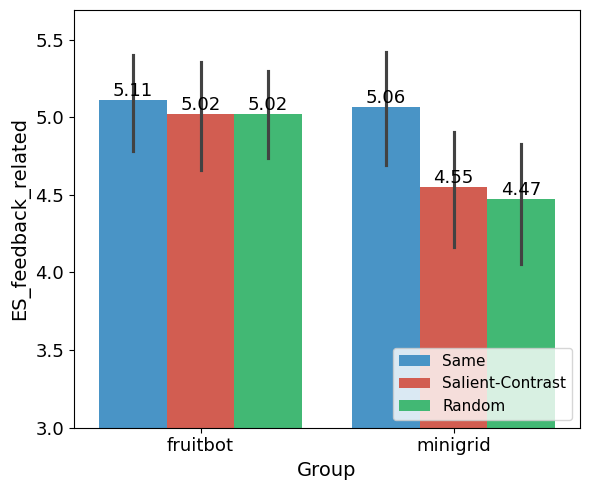

statistic tests for minigrid on ES_feedback_related:
         group_1          group_2      U      p
          Random Salient-Contrast 2766.5 0.4892
          Random             Same 1890.5 0.0210
Salient-Contrast             Same 1810.5 0.0208
statistic tests for fruitbot on ES_feedback_related:
         group_1          group_2      U      p
          Random Salient-Contrast 1336.5 0.3389
          Random             Same 1237.0 0.1756
Salient-Contrast             Same 1488.5 0.3769

--------------------------------------------------



In [142]:
# user satisfaction with the feedback and explanations
satisfaction_list = ['ES_feedback_related', 'ES_understandable', 'ES_overwhelming', 'ES_helpful', 'ES_improvement', 'ES_combined']
for y_column in satisfaction_list[:1]:
    print(user_question_mapping[y_column])
    user_results_p = user_results[user_results[y_column].notnull()].copy()
    user_results_p[y_column] = user_results_p[y_column].astype(int)
    plot_barplot(user_results_p, 'environment', y_column,
                y_label=y_column, palette=colors_palette, hue='group_label',
                estimator=lambda x: np.mean(x), bar_label_fmt='%.2f', ylim_bottom=3)
    for env in ['minigrid', 'fruitbot']:
        print(f"statistic tests for {env} on {y_column}:")
        mannwhitneyu_test(user_results_p[user_results_p['environment'] == env], y_column, 'group_label', test_type='less')
    print("\n" + "-"*50 + "\n")

## Choice Time

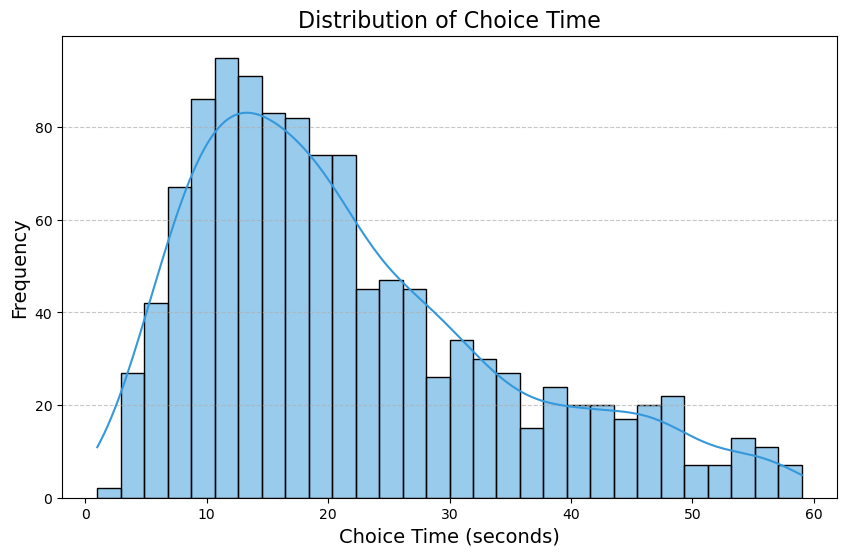

count    1160.000000
mean       21.781034
std        12.908932
min         1.000000
25%        12.000000
50%        19.000000
75%        29.000000
max        59.000000
Name: choice_time, dtype: float64

In [95]:
plt.figure(figsize=(10, 6))
plot_df = choices_results[(choices_results['choice_time'] < 60) & (choices_results['choice_time'] > 0)]  # Filter out extreme outliers for better visualization

sns.histplot(plot_df['choice_time'], kde=True, color='#3498db', bins=30)
plt.title('Distribution of Choice Time', fontsize=16)
plt.xlabel('Choice Time (seconds)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plot_df['choice_time'].describe()

handles: [<matplotlib.patches.Rectangle object at 0x000001D5CA82ADA0>, <matplotlib.patches.Rectangle object at 0x000001D5CA8281C0>, <matplotlib.patches.Rectangle object at 0x000001D5CA8285B0>], labels: ['Same', 'Random', 'Salient-Contrast'], display_labels: None


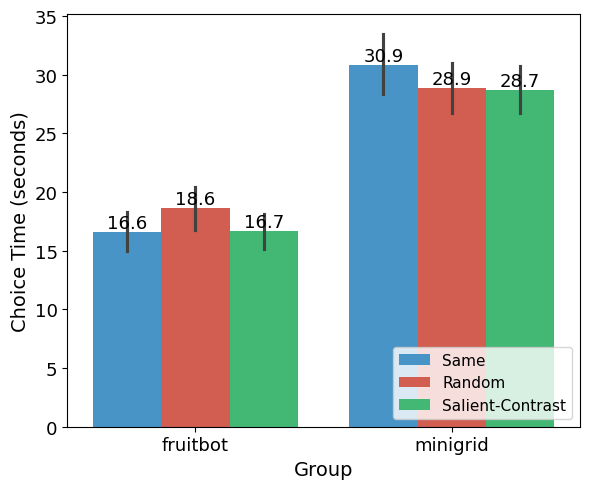

statistic tests for minigrid:
ANOVA F=1.0234, p=0.3600  |  Kruskal-Wallis H=1.6028, p=0.4487
         group_1          group_2       U      p
          Random Salient-Contrast 25696.5 0.5835
          Random             Same 21588.0 0.2102
Salient-Contrast             Same 18685.5 0.4642
statistic tests for fruitbot:
ANOVA F=1.7022, p=0.1832  |  Kruskal-Wallis H=1.8955, p=0.3876
         group_1          group_2       U      p
          Random Salient-Contrast 17820.0 0.4608
          Random             Same 18380.0 0.1695
Salient-Contrast             Same 19646.5 0.5094


In [133]:
plot_df = choices_results[(choices_results['choice_time'] < 80) & (choices_results['choice_time'] > 0)]  # Filter out extreme outliers for better visualization
if plot_df.empty:
    print("No valid choice_time data to plot.")
else:
    plot_barplot(plot_df, 'environment', 'choice_time', y_label='Choice Time (seconds)', 
                 hue='group_label', palette=colors_palette,
             bar_label_fmt='%.1f', estimator='mean')
    for env in ['minigrid', 'fruitbot']:
        print(f"statistic tests for {env}:")
        anova_test(plot_df[plot_df['environment'] == env], 'choice_time', 'group_label')
        mannwhitneyu_test(plot_df[plot_df['environment'] == env], 'choice_time', 'group_label')

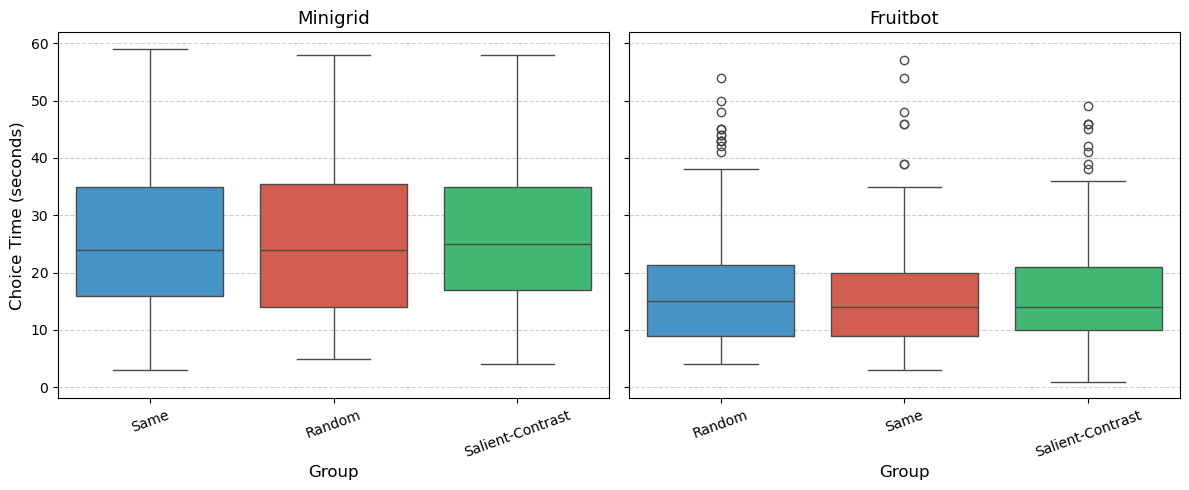

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
envs = ['minigrid', 'fruitbot']

for ax, env in zip(axes, envs):
    env_df = plot_df[plot_df['environment'] == env].copy()

    sns.boxplot(
        data=env_df,
        x='group_label',
        y='choice_time',
        palette=colors_palette,
        ax=ax
    )

    ax.set_title(env.capitalize(), fontsize=13)
    ax.set_xlabel('Group', fontsize=12)
    ax.set_ylabel('Choice Time (seconds)' if ax is axes[0] else '', fontsize=12)
    ax.tick_params(axis='x', labelrotation=20)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Delegation - Trust the Agent

handles: [<matplotlib.patches.Rectangle object at 0x000001D5C6A13100>, <matplotlib.patches.Rectangle object at 0x000001D5C6A129B0>, <matplotlib.patches.Rectangle object at 0x000001D5C6A10820>, <matplotlib.patches.Rectangle object at 0x000001D5C6A13D00>], labels: ['Same', 'Salient-Contrast', 'Control', 'Random'], display_labels: None


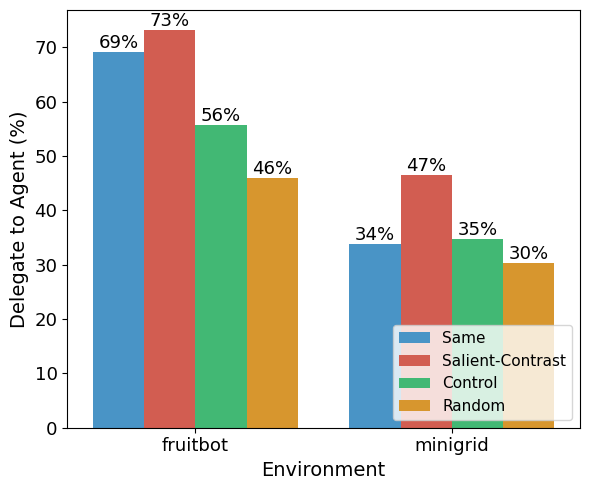

statistic tests for minigrid on trust_the_agent:
ANOVA F=1.5872, p=0.1927  |  Kruskal-Wallis H=4.7318, p=0.1925
         group_1          group_2      U      p
         Control           Random 2740.5 0.5645
         Control Salient-Contrast 2221.5 0.1552
         Control             Same 2158.5 0.9152
          Random Salient-Contrast 2321.5 0.0415
          Random             Same 2271.0 0.6541
Salient-Contrast             Same 2550.5 0.1365
statistic tests for fruitbot on trust_the_agent:
ANOVA F=3.5685, p=0.0150  |  Kruskal-Wallis H=10.3302, p=0.0160
         group_1          group_2      U      p
         Control           Random 1427.0 0.3281
         Control Salient-Contrast 1202.0 0.0595
         Control             Same 1239.5 0.1576
          Random Salient-Contrast 1019.0 0.0045
          Random             Same 1057.5 0.0173
Salient-Contrast             Same 1603.5 0.6358


In [139]:
# Plot: Delegate to Agent by Group
plot_barplot(user_results[user_results['final_agent'] > 0], 'environment', 'trust_the_agent', hue='group_label', errorbar=None, x_label='Environment',
             y_label='Delegate to Agent (%)', palette=colors_palette, bar_label_fmt='%.0f%%')

for env in ['minigrid', 'fruitbot']:
    print(f"statistic tests for {env} on trust_the_agent:")
    anova_test(user_results[user_results['environment'] == env], 'trust_the_agent', 'group_label')

    mannwhitneyu_test(user_results[user_results['environment'] == env], 'trust_the_agent', 'group_label', test_type='two-sided')

--- Trust the agent analysis for minigrid ---
handles: [<matplotlib.patches.Rectangle object at 0x000001D5C8BD53F0>, <matplotlib.patches.Rectangle object at 0x000001D5C8BD4FA0>, <matplotlib.patches.Rectangle object at 0x000001D5BFC6D390>, <matplotlib.patches.Rectangle object at 0x000001D5C77714B0>], labels: ['Control', 'Same', 'Random', 'Salient-Contrast'], display_labels: None


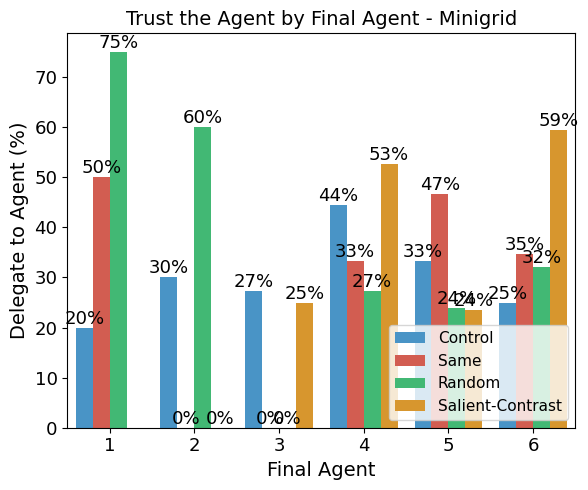

--- Trust the agent analysis for fruitbot ---
handles: [<matplotlib.patches.Rectangle object at 0x000001D5C8C154B0>, <matplotlib.patches.Rectangle object at 0x000001D5C8C14550>, <matplotlib.patches.Rectangle object at 0x000001D5C8C143A0>, <matplotlib.patches.Rectangle object at 0x000001D5C8C15420>], labels: ['Control', 'Same', 'Salient-Contrast', 'Random'], display_labels: None


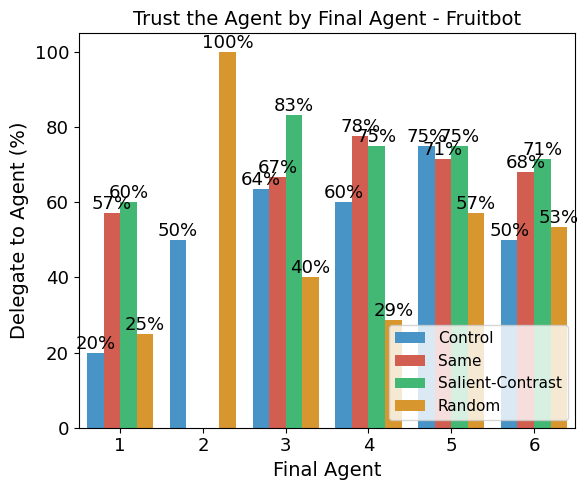

In [119]:
# traust the agent by final agent and by hue group, for each environment
for env in ['minigrid', 'fruitbot']:
    print(f"--- Trust the agent analysis for {env} ---")
    env_df = user_results[user_results['environment'] == env].copy()
    plot_barplot(env_df, 'final_agent', 'trust_the_agent', hue='group_label',
                 y_label='Delegate to Agent (%)', x_label='Final Agent',
                 palette=colors_palette, bar_label_fmt='%.0f%%', errorbar=None, title=f"Trust the Agent by Final Agent - {env.capitalize()}")

Trend summary (sorted by slope within environment):


,environment,group_label,n,slope_per_rank,spearman_rho,trust_mean_low_1_2,trust_mean_high_5_6,high_low_gap
1,fruitbot,Random,50,0.0529,0.1818,0.3333,0.5517,0.2184
0,fruitbot,Control,52,0.0330,0.0635,0.2857,0.5833,0.2976
3,fruitbot,Same,55,0.0171,0.0195,0.5714,0.6944,0.1230
2,fruitbot,Salient-Contrast,56,0.0079,-0.0105,0.6000,0.7317,0.1317
6,minigrid,Salient-Contrast,73,0.0799,0.1662,0.0000,0.4694,0.4694
7,minigrid,Same,62,0.0411,0.1132,0.3333,0.3947,0.0614
4,minigrid,Control,69,0.0266,0.0682,0.2667,0.3125,0.0458
5,minigrid,Random,76,-0.0394,-0.0523,0.6667,0.2857,-0.3810


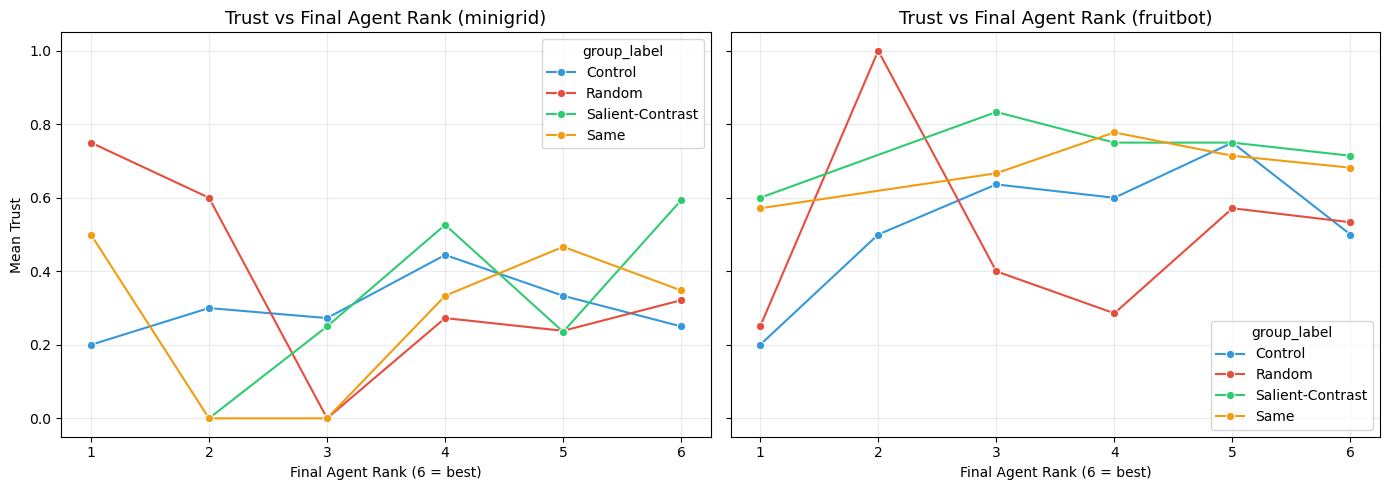

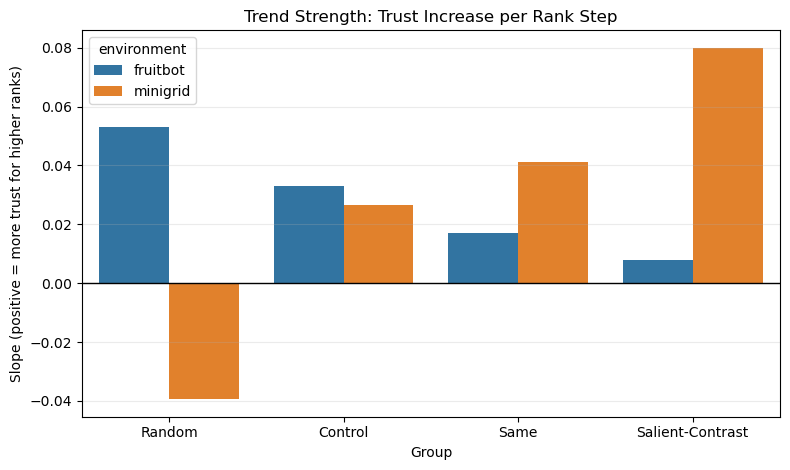

In [121]:
# Trend analysis (without significance testing):
# "Better" here means stronger increase in trust for higher final agent ranks.


trend_df = user_results.dropna(subset=['environment', 'group_label', 'final_agent', 'trust_the_agent']).copy()
trend_df['final_agent'] = pd.to_numeric(trend_df['final_agent'], errors='coerce')
trend_df['trust_the_agent'] = pd.to_numeric(trend_df['trust_the_agent'], errors='coerce')
trend_df = trend_df.dropna(subset=['final_agent', 'trust_the_agent'])

# 1) Mean trust by rank (1..6) for each group inside each environment
mean_trend = (
    trend_df
    .groupby(['environment', 'group_label', 'final_agent'], as_index=False)['trust_the_agent']
    .mean()
    .sort_values(['environment', 'group_label', 'final_agent'])
)

# 2) Trend metrics per (environment, group):
#    - slope_per_rank: linear trend of trust as rank increases
#    - high_low_gap: mean trust(5-6) - mean trust(1-2), positive means desired trend
summary_rows = []
for (env, grp), dfg in trend_df.groupby(['environment', 'group_label']):
    dfg = dfg.sort_values('final_agent')
    x = dfg['final_agent'].values
    y = dfg['trust_the_agent'].values

    if len(np.unique(x)) > 1:
        slope = np.polyfit(x, y, 1)[0]
        spearman_rho = dfg['final_agent'].corr(dfg['trust_the_agent'], method='spearman')
    else:
        slope = np.nan
        spearman_rho = np.nan

    hi = dfg[dfg['final_agent'].isin([5, 6])]['trust_the_agent'].mean()
    lo = dfg[dfg['final_agent'].isin([1, 2])]['trust_the_agent'].mean()
    high_low_gap = hi - lo if (not np.isnan(hi) and not np.isnan(lo)) else np.nan

    summary_rows.append({
        'environment': env,
        'group_label': grp,
        'n': len(dfg),
        'slope_per_rank': slope,
        'spearman_rho': spearman_rho,
        'trust_mean_low_1_2': lo,
        'trust_mean_high_5_6': hi,
        'high_low_gap': high_low_gap
    })

trend_summary = pd.DataFrame(summary_rows).sort_values(['environment', 'slope_per_rank'], ascending=[True, False])
print('Trend summary (sorted by slope within environment):')
display(trend_summary.round(4))

# 3) Plot trends
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, env in zip(axes, ['minigrid', 'fruitbot']):
    env_df = mean_trend[mean_trend['environment'] == env]
    sns.lineplot(
        data=env_df,
        x='final_agent',
        y='trust_the_agent',
        hue='group_label',
        marker='o',
        palette=colors_palette,
        ax=ax
    )
    ax.set_title(f'Trust vs Final Agent Rank ({env})', fontsize=13)
    ax.set_xlabel('Final Agent Rank (6 = best)')
    ax.set_ylabel('Mean Trust' if ax is axes[0] else '')
    ax.set_xticks([1, 2, 3, 4, 5, 6])
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# 4) Compact ranking view for quick comparison
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(
    data=trend_summary,
    x='group_label',
    y='slope_per_rank',
    hue='environment',
    palette=['#1f77b4', '#ff7f0e'],
    ax=ax
    )
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Trend Strength: Trust Increase per Rank Step')
ax.set_xlabel('Group')
ax.set_ylabel('Slope (positive = more trust for higher ranks)')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

### How to read the trend plots and table

- **Line plots (left/right):** Each line is one group. If a line generally rises from rank 1 to rank 6, that group tends to trust higher-ranked agents more.
- **`slope_per_rank`:** Average trust change when rank increases by 1. Higher positive values mean a stronger positive trend.
- **`high_low_gap`:** Mean trust at ranks 5-6 minus mean trust at ranks 1-2. Positive values indicate more trust for top-ranked agents.
- **`spearman_rho`:** Monotonic trend indicator. Values closer to +1 mean stronger increasing trend, near 0 means weak/no trend, negative means opposite trend.
- This section is **trend-focused** only: use it to compare direction and relative strength, not to claim statistical significance.

Evaluate-final-agent trend summary (sorted by slope within environment):


,environment,group_label,n,slope_per_rank,spearman_rho,eval_mean_low_1_2,eval_mean_high_5_6,high_low_gap
3,fruitbot,Same,55,0.1625,0.1594,4.0000,4.8611,0.8611
1,fruitbot,Random,50,0.1418,0.1810,4.3333,4.7241,0.3908
0,fruitbot,Control,53,0.1222,0.0885,2.7143,4.0400,1.3257
2,fruitbot,Salient-Contrast,56,0.0797,0.0197,4.0000,4.5854,0.5854
7,minigrid,Same,62,0.1704,0.0952,2.6667,3.3158,0.6491
6,minigrid,Salient-Contrast,73,0.0489,-0.0037,3.0000,3.5918,0.5918
5,minigrid,Random,76,-0.0975,-0.1275,3.6667,3.1020,-0.5646
4,minigrid,Control,69,-0.2516,-0.1267,4.1333,2.8750,-1.2583


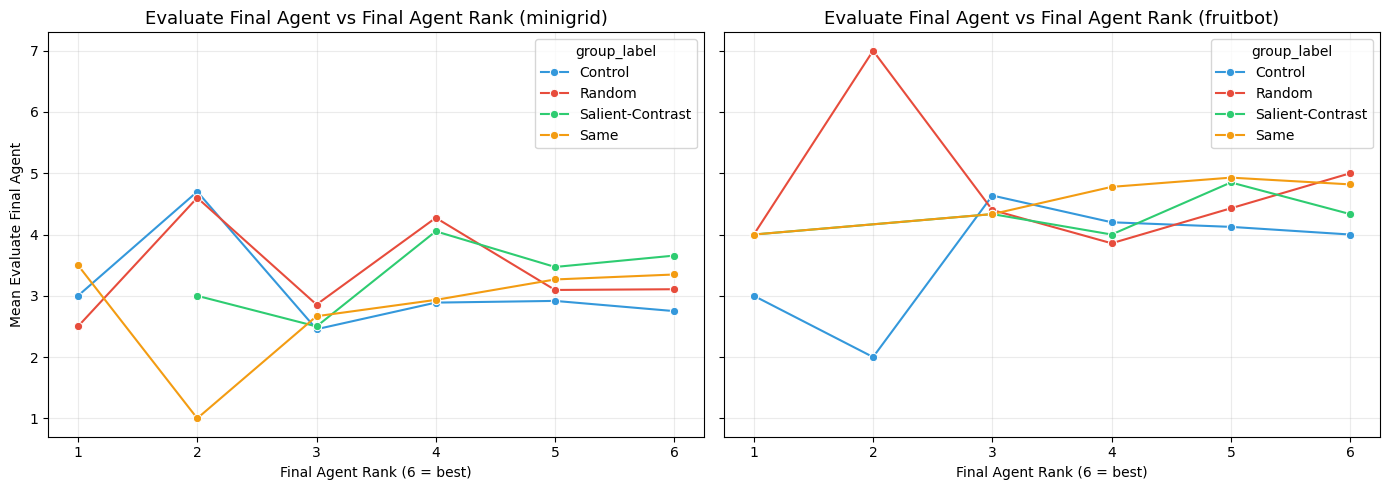

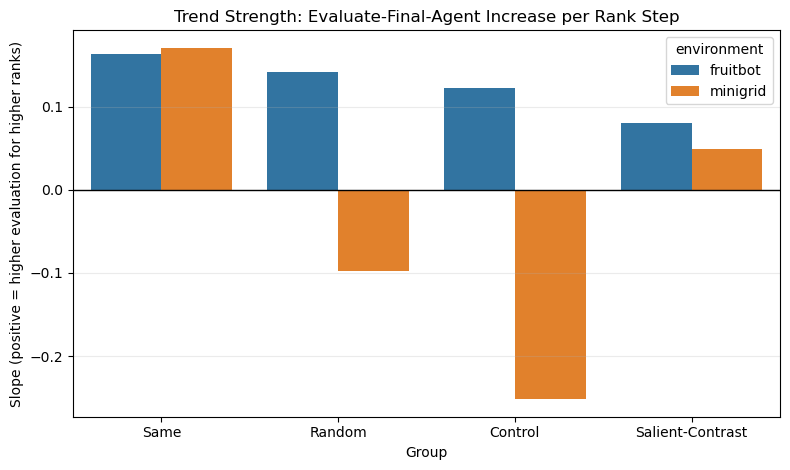

In [123]:
# Trend analysis (without significance testing):
# "Better" here means stronger increase in evaluate_final_agent for higher final agent ranks.


eval_trend_df = user_results.dropna(subset=['environment', 'group_label', 'final_agent', 'evaluate_final_agent']).copy()
eval_trend_df['final_agent'] = pd.to_numeric(eval_trend_df['final_agent'], errors='coerce')
eval_trend_df['evaluate_final_agent'] = pd.to_numeric(eval_trend_df['evaluate_final_agent'], errors='coerce')
eval_trend_df = eval_trend_df.dropna(subset=['final_agent', 'evaluate_final_agent'])

# 1) Mean evaluation by rank (1..6) for each group inside each environment
eval_mean_trend = (
    eval_trend_df
    .groupby(['environment', 'group_label', 'final_agent'], as_index=False)['evaluate_final_agent']
    .mean()
    .sort_values(['environment', 'group_label', 'final_agent'])
)

# 2) Trend metrics per (environment, group):
#    - slope_per_rank: linear trend of evaluation as rank increases
#    - high_low_gap: mean eval(5-6) - mean eval(1-2), positive means desired trend
eval_summary_rows = []
for (env, grp), dfg in eval_trend_df.groupby(['environment', 'group_label']):
    dfg = dfg.sort_values('final_agent')
    x = dfg['final_agent'].values
    y = dfg['evaluate_final_agent'].values

    if len(np.unique(x)) > 1:
        slope = np.polyfit(x, y, 1)[0]
        spearman_rho = dfg['final_agent'].corr(dfg['evaluate_final_agent'], method='spearman')
    else:
        slope = np.nan
        spearman_rho = np.nan

    hi = dfg[dfg['final_agent'].isin([5, 6])]['evaluate_final_agent'].mean()
    lo = dfg[dfg['final_agent'].isin([1, 2])]['evaluate_final_agent'].mean()
    high_low_gap = hi - lo if (not np.isnan(hi) and not np.isnan(lo)) else np.nan

    eval_summary_rows.append({
        'environment': env,
        'group_label': grp,
        'n': len(dfg),
        'slope_per_rank': slope,
        'spearman_rho': spearman_rho,
        'eval_mean_low_1_2': lo,
        'eval_mean_high_5_6': hi,
        'high_low_gap': high_low_gap
    })

eval_trend_summary = pd.DataFrame(eval_summary_rows).sort_values(['environment', 'slope_per_rank'], ascending=[True, False])
print('Evaluate-final-agent trend summary (sorted by slope within environment):')
display(eval_trend_summary.round(4))

# 3) Plot trends
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, env in zip(axes, ['minigrid', 'fruitbot']):
    env_df = eval_mean_trend[eval_mean_trend['environment'] == env]
    sns.lineplot(
        data=env_df,
        x='final_agent',
        y='evaluate_final_agent',
        hue='group_label',
        marker='o',
        palette=colors_palette,
        ax=ax
    )
    ax.set_title(f'Evaluate Final Agent vs Final Agent Rank ({env})', fontsize=13)
    ax.set_xlabel('Final Agent Rank (6 = best)')
    ax.set_ylabel('Mean Evaluate Final Agent' if ax is axes[0] else '')
    ax.set_xticks([1, 2, 3, 4, 5, 6])
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# 4) Compact ranking view for quick comparison
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(
    data=eval_trend_summary,
    x='group_label',
    y='slope_per_rank',
    hue='environment',
    palette=['#1f77b4', '#ff7f0e'],
    ax=ax
    )
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Trend Strength: Evaluate-Final-Agent Increase per Rank Step')
ax.set_xlabel('Group')
ax.set_ylabel('Slope (positive = higher evaluation for higher ranks)')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

### How to read this evaluate_final_agent trend section

- **Line plots:** Upward lines mean users tend to rate/evaluate the final agent higher when the selected final rank is higher.
- **`slope_per_rank`:** Main trend strength measure. Larger positive values = stronger positive trend.
- **`high_low_gap`:** Mean evaluation at ranks 5-6 minus ranks 1-2. Positive means top-ranked agents are evaluated more favorably.
- **`spearman_rho`:** Monotonic trend indicator. Closer to +1 is stronger increasing trend.
- This is a **trend view**, not a significance claim. Use it for directional and relative comparisons between groups.


Final Agent Mean Score by Group and Trust the Agent for **minigrid**:
handles: [<matplotlib.patches.Rectangle object at 0x000001D5C699CCD0>, <matplotlib.patches.Rectangle object at 0x000001D5C699CF40>], labels: ['0.0', '1.0'], display_labels: None


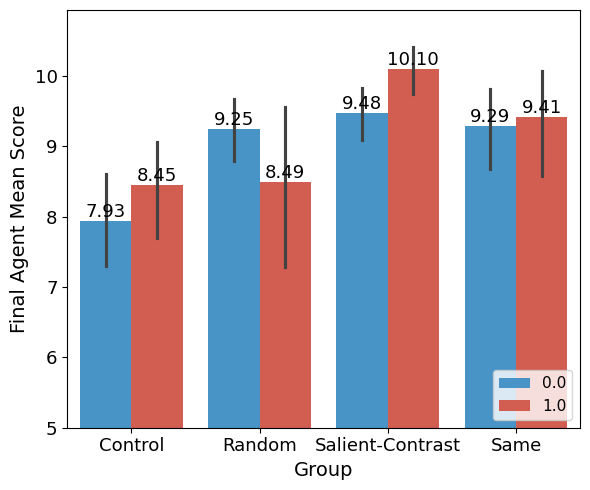


Mann-Whitney U Test for minigrid:
Similar
Empty DataFrame
Columns: []
Index: []
Contrast
Empty DataFrame
Columns: []
Index: []
Same
 group_1  group_2     U      p
     0.0      1.0 403.5 0.6811
Random
 group_1  group_2     U      p
     0.0      1.0 640.0 0.7243

Final Agent Mean Score by Group and Trust the Agent for **fruitbot**:
handles: [<matplotlib.patches.Rectangle object at 0x000001D5C690AF50>, <matplotlib.patches.Rectangle object at 0x000001D5C690ADA0>], labels: ['0.0', '1.0'], display_labels: None


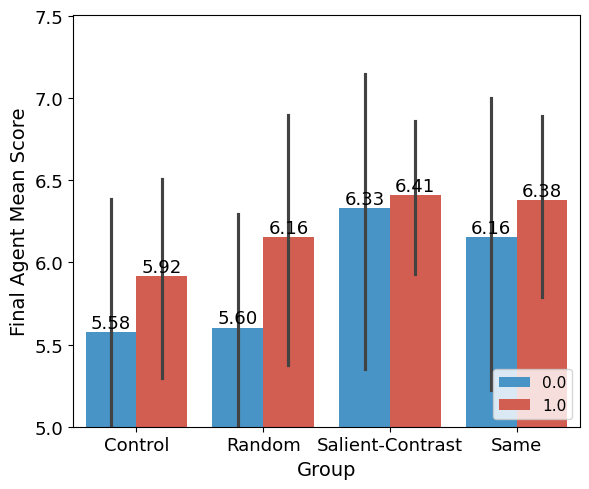


Mann-Whitney U Test for fruitbot:
Similar
Empty DataFrame
Columns: []
Index: []
Contrast
Empty DataFrame
Columns: []
Index: []
Same
 group_1  group_2     U      p
     0.0      1.0 315.5 0.8939
Random
 group_1  group_2     U      p
     0.0      1.0 253.0 0.2534


In [100]:
# Final agent score by group and trust the agent
for env in ['minigrid', 'fruitbot']:
    print(f"\nFinal Agent Mean Score by Group and Trust the Agent for **{env}**:")
    plot_barplot(user_results[user_results['environment'] == env], 'group_label', 'final_agent_mean_score', hue='trust_the_agent',
             y_label='Final Agent Mean Score', x_label='Group',
             estimator = 'mean', bar_label_fmt='%.2f', ylim_bottom=5,
            palette=colors_palette)

    print(f"\nMann-Whitney U Test for {env}:")
    print("Similar")
    mannwhitneyu_test(user_results[user_results['environment'] == env][user_results[user_results['environment'] == env]['group_label'] == 'Similar'], 'final_agent_mean_score', 'trust_the_agent')
    print("Contrast")
    mannwhitneyu_test(user_results[user_results['environment'] == env][user_results[user_results['environment'] == env]['group_label'] == 'Contrast'], 'final_agent_mean_score', 'trust_the_agent')
    print("Same")
    mannwhitneyu_test(user_results[user_results['environment'] == env][user_results[user_results['environment'] == env]['group_label'] == 'Same'], 'final_agent_mean_score', 'trust_the_agent')
    print("Random")
    mannwhitneyu_test(user_results[user_results['environment'] == env][user_results[user_results['environment'] == env]['group_label'] == 'Random'], 'final_agent_mean_score', 'trust_the_agent')

In [101]:
user_results.columns

Index(['user_id', 'group', 'trust_the_agent', 'number_of_choices',
       'final_agent_mean_score', 'user_performance', 'age', 'gender',
       'education', 'familiar_with_AI', 'evaluate_final_agent', 'AI_1',
       'ES_understandable', 'AI_2', 'autentication_check', 'AI_3',
       'ES_overwhelming', 'AI_4', 'ES_feedback_related', 'AI_5', 'ES_helpful',
       'group_label', 'mean_good_choice_local', 'mean_good_choice_global',
       'mean_good_choice_demo', 'final_agent', 'environment', 'ES_improvement',
       'mean_agent_rating', 'final_score', 'ES_combined'],
      dtype='object')

In [102]:
user_results['trust_the_agent'].value_counts()

trust_the_agent
0.0    260
1.0    233
Name: count, dtype: int64

## Final Agent

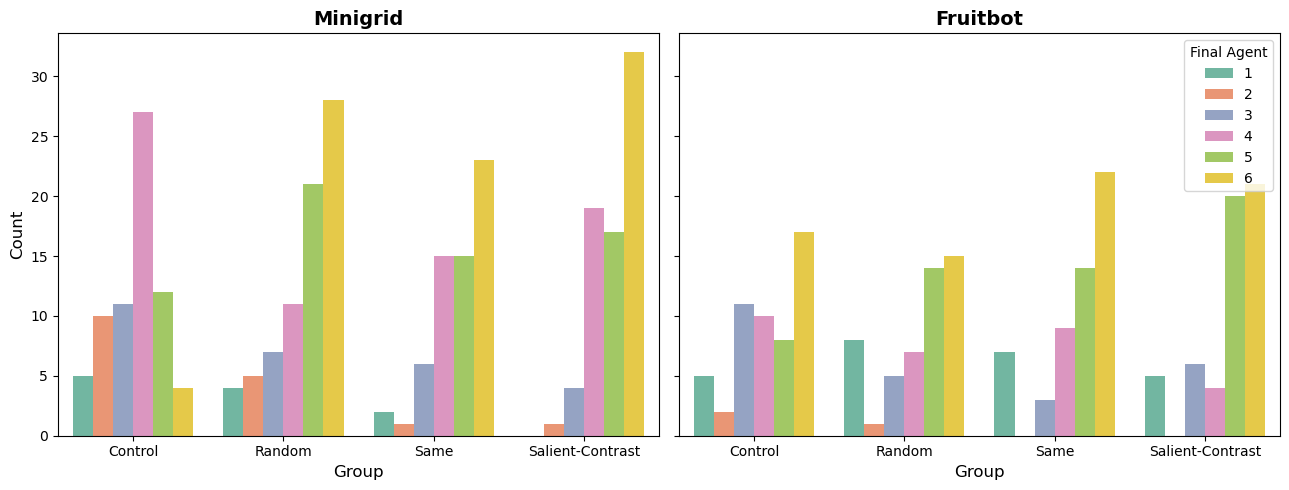

In [126]:
# Plot: Count of Final Agent by Group (side-by-side: Minigrid and Fruitbot)
ordered_groups = ['Control', 'Random', 'Same', 'Salient-Contrast']
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, env in zip(axes, ['minigrid', 'fruitbot']):
    grouped = (
        user_results[user_results['environment'] == env]
        .groupby(['group_label', 'final_agent'])
        .size()
        .reset_index(name='count')
    )

    sns.barplot(
        data=grouped,
        x='group_label',
        y='count',
        hue='final_agent',
        order=ordered_groups,
        palette='Set2',
        ax=ax
    )

    ax.set_title('Minigrid' if env == 'minigrid' else 'Fruitbot', fontsize=14, fontweight='bold')
    ax.set_xlabel('Group', fontsize=12)
    ax.set_ylabel('Count' if env == 'minigrid' else '', fontsize=12)
    ax.tick_params(axis='x', rotation=0)

# Keep legend only on Fruitbot (right panel), upper-right
axes[0].legend_.remove()
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles, labels=labels, title='Final Agent', loc='upper right')

plt.tight_layout()
plt.show()

handles: [<matplotlib.patches.Rectangle object at 0x000001D5C6370550>, <matplotlib.patches.Rectangle object at 0x000001D5C6371990>, <matplotlib.patches.Rectangle object at 0x000001D5C6370100>, <matplotlib.patches.Rectangle object at 0x000001D5C6373970>], labels: ['Same', 'Salient-Contrast', 'Control', 'Random'], display_labels: None


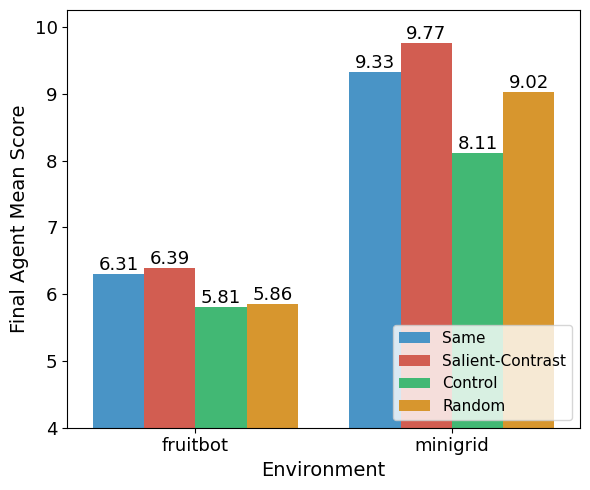

statistic tests for minigrid:
ANOVA F=10.0882, p=0.0000  |  Kruskal-Wallis H=27.9999, p=0.0000
         group_1          group_2      U      p
         Control           Random 1926.0 0.0049
         Control Salient-Contrast 1278.5 0.0000
         Control             Same 1346.5 0.0002
          Random Salient-Contrast 2249.5 0.0369
          Random             Same 2165.5 0.3976
Salient-Contrast             Same 2521.5 0.2305
statistic tests for fruitbot:
ANOVA F=1.4569, p=0.2274  |  Kruskal-Wallis H=4.5913, p=0.2043
         group_1          group_2      U      p
         Control           Random 1274.0 0.7324
         Control Salient-Contrast 1204.0 0.0796
         Control             Same 1212.0 0.1196
          Random Salient-Contrast 1183.5 0.1550
          Random             Same 1196.0 0.2351
Salient-Contrast             Same 1570.5 0.8528


In [104]:
# Final agent score by group and trust the agent

plot_barplot(user_results, 'environment', 'final_agent_mean_score', hue='group_label', errorbar=None, x_label='Environment',
            y_label='Final Agent Mean Score', ylim_bottom=4,
            estimator = 'mean', bar_label_fmt='%.2f', 
        palette=colors_palette)

# statistic tests for final agent score by group
for env in ['minigrid', 'fruitbot']:
    print(f"statistic tests for {env}:")
    anova_test(user_results[user_results['environment'] == env], 'final_agent_mean_score', 'group_label')
    mannwhitneyu_test(user_results[user_results['environment'] == env], 'final_agent_mean_score', 'group_label', test_type='two-sided')

handles: [<matplotlib.patches.Rectangle object at 0x000001D5C0294100>, <matplotlib.patches.Rectangle object at 0x000001D5C62B2950>], labels: ['Assesment-Loop', 'Control'], display_labels: None


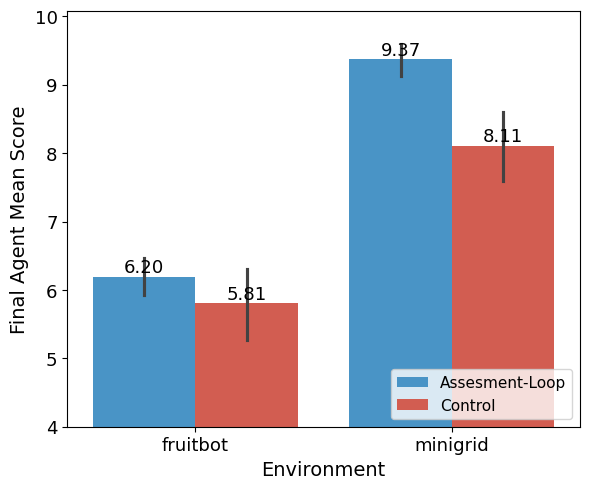

statistic tests for minigrid:
       group_1 group_2       U   p
Assesment-Loop Control 10008.0 0.0
statistic tests for fruitbot:
       group_1 group_2      U      p
Assesment-Loop Control 4843.0 0.0636


In [105]:

plot_df = user_results.copy()
plot_df['group_binary'] = np.where(plot_df['group_label'] == 'Control', 'Control', 'Assesment-Loop')

plot_barplot(
    plot_df,
    'environment',
    'final_agent_mean_score',
    hue='group_binary',
    estimator='mean',
    x_label='Environment',
    y_label='Final Agent Mean Score',
    palette=['#3498db', '#e74c3c'],
    bar_label_fmt='%.2f',
    ylim_bottom=4

 )

for env in ['minigrid', 'fruitbot']:
    print(f"statistic tests for {env}:")
    mannwhitneyu_test(plot_df[plot_df['environment'] == env], 'final_agent_mean_score', 'group_binary', test_type='greater')

## Config Change


In [106]:
plot_df = choices_results[choices_results['demonstration_config'] >= 0].copy()
plot_df['config_change'] = plot_df.apply(lambda r: f"{r['feedback_config']}-{r['demonstration_config']}", axis=1)

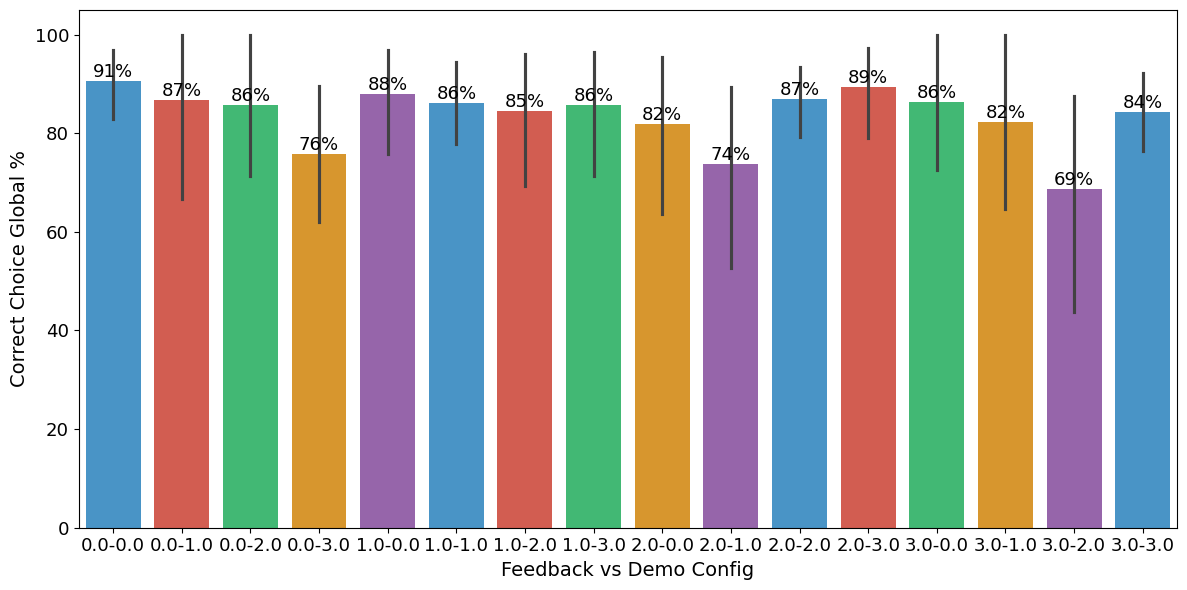

config_change
3.0-3.0    89
2.0-2.0    77
1.0-1.0    72
0.0-0.0    64
2.0-3.0    38
1.0-0.0    33
0.0-3.0    29
1.0-3.0    28
1.0-2.0    26
2.0-0.0    22
3.0-0.0    22
0.0-2.0    21
2.0-1.0    19
3.0-1.0    17
3.0-2.0    16
0.0-1.0    15
Name: count, dtype: int64

In [107]:

plot_barplot(plot_df, 'config_change', 'good_choice_demo', y_label='Correct Choice Global %',# hue='group_label',
             x_label='Feedback vs Demo Config', palette=colors_palette, figsize=(12,6), bar_label_fmt='%.f%%')

plot_df['config_change'].value_counts()

# More plots

In [108]:
choices_results.columns

Index(['user_id', 'episode_index', 'group', 'trust_the_agent',
       'feedback_correctness', 'prev_agent', 'updated_agent',
       'prev_agent_mean_score', 'update_agent_mean_score',
       'prev_agent_feedback_score', 'updated_agent_feedback_score', 'choice',
       'good_choice_global', 'good_choice_local', 'choice_time',
       'examples_shown', 'feedback_level', 'demonstration_level',
       'good_choice_demo', 'prev_agent_demo_score', 'update_agent_demo_score',
       'improved_from_prev_feedback', 'improved_from_prev_mean', 'group_label',
       'environment', 'feedback_config', 'demonstration_config',
       'feedback_count', 'agent_rating'],
      dtype='object')

In [109]:
plot_df = choices_results[choices_results['agent_rating'].notnull()].copy()

print(plot_df['prev_agent_demo_score'].describe())


count    588.000000
mean       5.006803
std        7.188147
min       -7.000000
25%       -2.000000
50%        8.000000
75%       11.000000
max       16.000000
Name: prev_agent_demo_score, dtype: float64


count    588.000000
mean       7.586735
std        6.585382
min       -7.000000
25%        0.000000
50%       10.000000
75%       13.000000
max       16.000000
Name: selected_agent_demo_score, dtype: float64
handles: [<matplotlib.patches.Rectangle object at 0x000001D5C62037C0>, <matplotlib.patches.Rectangle object at 0x000001D5C62449D0>, <matplotlib.patches.Rectangle object at 0x000001D5C6244FD0>, <matplotlib.patches.Rectangle object at 0x000001D5C62448E0>], labels: ['Salient-Contrast', 'Same', 'Random', 'Control'], display_labels: None


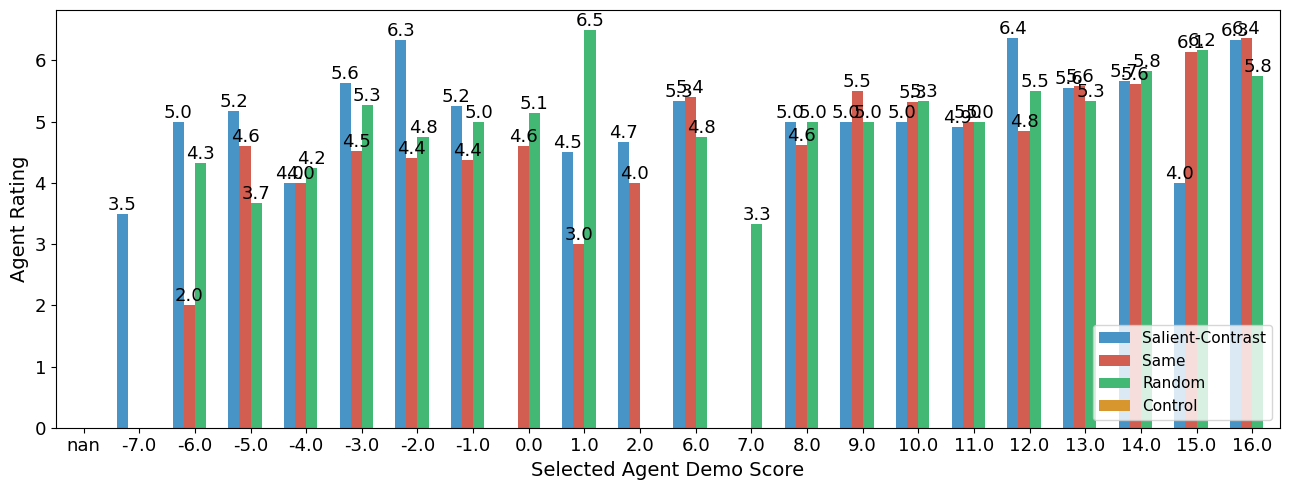

In [110]:
plot_df = choices_results[choices_results['agent_rating'].notnull()].copy()
plot_df['selected_agent_demo_score'] = plot_df['prev_agent_demo_score'] * (1 - plot_df['good_choice_demo']) + plot_df['update_agent_demo_score'] * plot_df['good_choice_demo']
print(plot_df['selected_agent_demo_score'].describe())
plot_barplot(plot_df, 'selected_agent_demo_score', 'agent_rating', hue='group_label', palette=colors_palette, y_label='Agent Rating', x_label='Selected Agent Demo Score',
             estimator='mean', bar_label_fmt='%.1f', figsize=(13,5), errorbar=None)

group_label       demonstration_config
Random            0.0                     49
                  1.0                     43
                  2.0                     44
                  3.0                     49
Salient-Contrast  0.0                     48
                  1.0                     27
                  2.0                     47
                  3.0                     76
Same              0.0                     44
                  1.0                     53
                  2.0                     49
                  3.0                     59
Name: good_choice_global, dtype: int64
handles: [<matplotlib.patches.Rectangle object at 0x000001D5C07FC940>, <matplotlib.patches.Rectangle object at 0x000001D5C07FC490>, <matplotlib.patches.Rectangle object at 0x000001D5C63258A0>], labels: ['Random', 'Same', 'Salient-Contrast'], display_labels: None


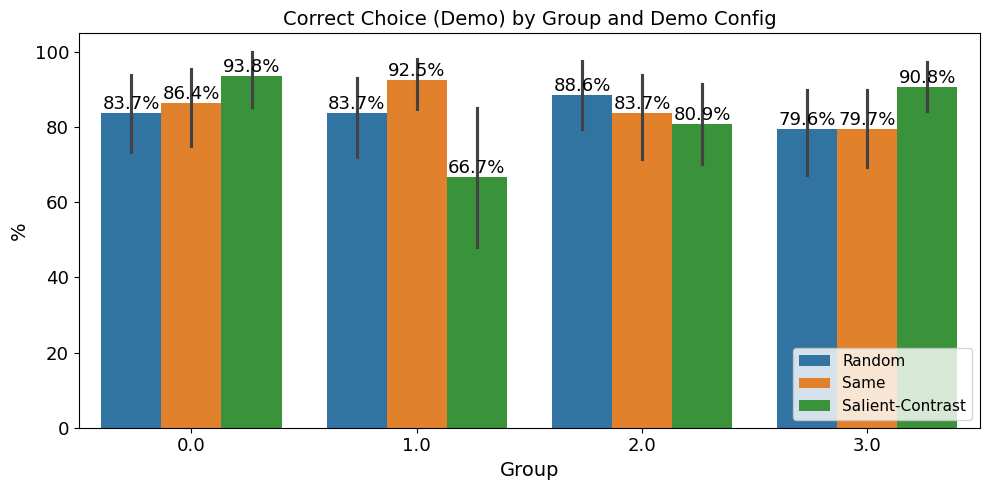

In [111]:
plot_df = choices_results.dropna(subset=['good_choice_demo', 'demonstration_config'])
plot_df = plot_df[plot_df['demonstration_config'] >= 0]
print(plot_df.groupby(['group_label', 'demonstration_config'])['good_choice_global'].count())
plot_barplot(plot_df, 'demonstration_config', 'good_choice_demo', hue='group_label',   
             figsize=(10,5),title='Correct Choice (Demo) by Group and Demo Config')

In [112]:
choices_results.columns

Index(['user_id', 'episode_index', 'group', 'trust_the_agent',
       'feedback_correctness', 'prev_agent', 'updated_agent',
       'prev_agent_mean_score', 'update_agent_mean_score',
       'prev_agent_feedback_score', 'updated_agent_feedback_score', 'choice',
       'good_choice_global', 'good_choice_local', 'choice_time',
       'examples_shown', 'feedback_level', 'demonstration_level',
       'good_choice_demo', 'prev_agent_demo_score', 'update_agent_demo_score',
       'improved_from_prev_feedback', 'improved_from_prev_mean', 'group_label',
       'environment', 'feedback_config', 'demonstration_config',
       'feedback_count', 'agent_rating'],
      dtype='object')

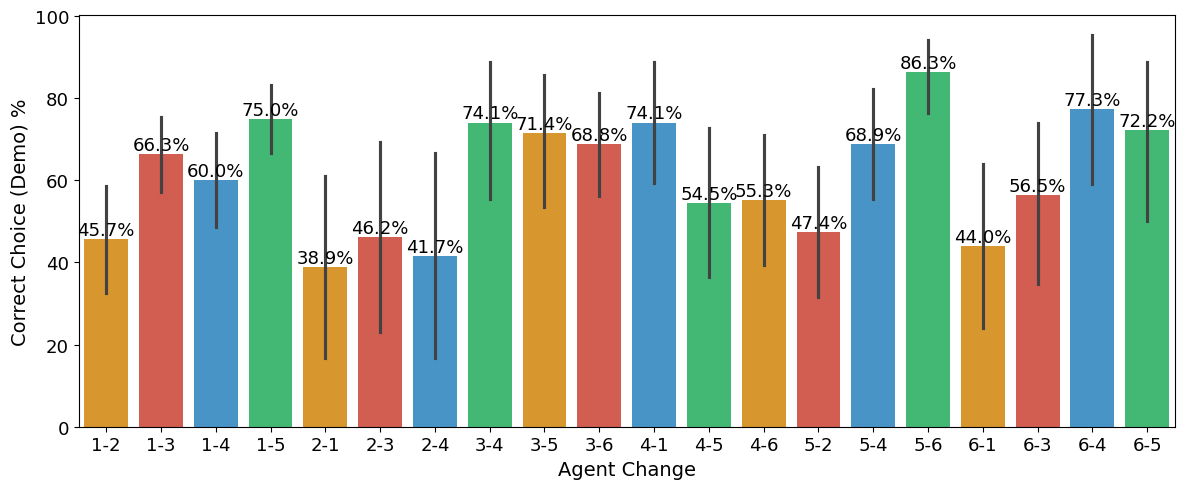

agent_change
1-5    108
1-3     98
1-4     70
5-6     51
3-6     48
1-2     46
5-4     45
4-6     38
5-2     38
3-5     28
4-1     27
3-4     27
6-1     25
6-3     23
6-4     22
4-5     22
2-1     18
6-5     18
2-3     13
2-4     12
Name: count, dtype: int64

In [113]:
plot_df = choices_results.copy()
plot_df["agent_change"] = plot_df.apply(lambda r: f"{r['prev_agent']}-{r['updated_agent']}", axis=1)
plot_barplot(plot_df[plot_df['environment'] == 'fruitbot'], 'agent_change', 'good_choice_demo',
             y_label='Correct Choice (Demo) %', x_label='Agent Change',
             figsize=(12, 5),
            #  x_val_names=plot_df['agent_change'].unique(),
             palette=['#f39c12', '#e74c3c', '#3498db', '#2ecc71'])
plot_df[plot_df['environment'] == 'fruitbot']['agent_change'].value_counts()

In [114]:
choices_results.columns

Index(['user_id', 'episode_index', 'group', 'trust_the_agent',
       'feedback_correctness', 'prev_agent', 'updated_agent',
       'prev_agent_mean_score', 'update_agent_mean_score',
       'prev_agent_feedback_score', 'updated_agent_feedback_score', 'choice',
       'good_choice_global', 'good_choice_local', 'choice_time',
       'examples_shown', 'feedback_level', 'demonstration_level',
       'good_choice_demo', 'prev_agent_demo_score', 'update_agent_demo_score',
       'improved_from_prev_feedback', 'improved_from_prev_mean', 'group_label',
       'environment', 'feedback_config', 'demonstration_config',
       'feedback_count', 'agent_rating'],
      dtype='object')

handles: [<matplotlib.patches.Rectangle object at 0x000001D5C73E0AC0>, <matplotlib.patches.Rectangle object at 0x000001D5C73E0100>, <matplotlib.patches.Rectangle object at 0x000001D5C7408490>, <matplotlib.patches.Rectangle object at 0x000001D5C7409B40>], labels: ['Control', 'Random', 'Same', 'Salient-Contrast'], display_labels: None


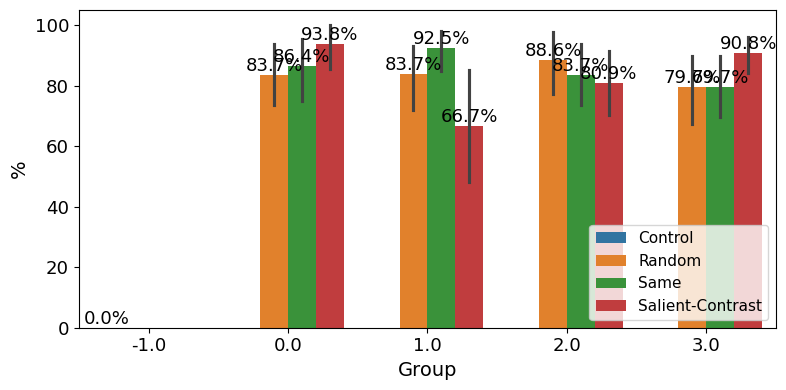

In [115]:
plot_barplot(choices_results[choices_results['environment'] == 'fruitbot'], 
             'demonstration_config', 'good_choice_demo', hue='group_label', figsize=(8, 4))

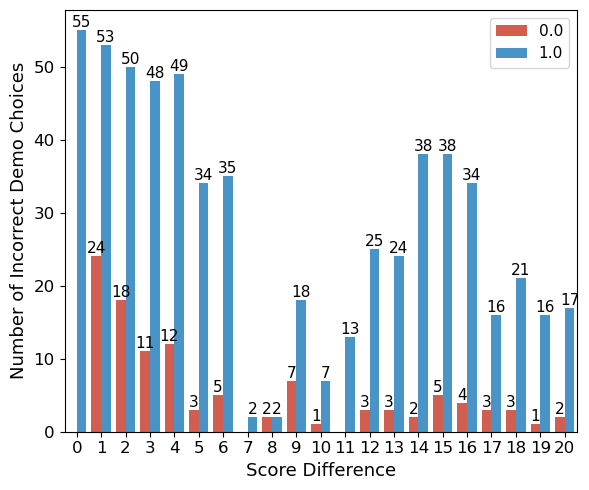

In [ ]:

plot_df = choices_results[choices_results['good_choice_demo'] == 0].copy()
plot_df = choices_results[choices_results['demo_prev_score'].notnull()].copy()
plot_df["agent_change"] = plot_df.apply(lambda r: f"{r['prev_agent']}-{r['updated_agent']}", axis=1)
plot_df['demo_score_diff'] = plot_df.apply(lambda r: int(np.abs(r['demo_prev_score'] - r['demo_updated_score'])), axis=1)
plot_barplot(plot_df, 'demo_score_diff', 'choice',
             y_label='Number of Incorrect Demo Choices', x_label='Score Difference',
             estimator=len, hue='good_choice_demo',
             bar_label_fmt='%.0f',
            #  x_val_names=plot_df['agent_change'].unique(),
             palette=['#e74c3c', '#3498db', '#2ecc71'])

In [ ]:
# Analysis of bad demonstration choices by different conditions

def analyze_bad_choices(df, condition_col, condition_name):
    """Calculate bad choice rate for each level of a condition"""
    summary = df.groupby(condition_col).agg({
        'good_choice_demo': ['count', 'sum']
    }).reset_index()
    summary.columns = [condition_col, 'total_choices', 'good_choices']
    summary['bad_choices'] = summary['total_choices'] - summary['good_choices']
    summary['bad_choice_rate'] = (summary['bad_choices'] / summary['total_choices'] * 100).round(2)
    summary['good_choice_rate'] = (summary['good_choices'] / summary['total_choices'] * 100).round(2)
    
    print(f"\n{'='*70}")
    print(f"{condition_name}")
    print(f"{'='*70}")
    print(summary.to_string(index=False))
    return summary

# Analyze by different conditions
summary_group = analyze_bad_choices(choices_results, 'group_label', 'BAD CHOICE RATE BY GROUP')
summary_config = analyze_bad_choices(choices_results, 'demonstration_config', 'BAD CHOICE RATE BY DEMONSTRATION CONFIG')
summary_episode = analyze_bad_choices(choices_results, 'episode_index', 'BAD CHOICE RATE BY EPISODE INDEX')
summary_choice = analyze_bad_choices(choices_results, 'choice', 'BAD CHOICE RATE BY USER CHOICE (0=Stay, 1=Update)')

# Overall statistics
total = len(choices_results)
bad_total = (choices_results['good_choice_demo'] == 0).sum()
print(f"\n{'='*70}")
print(f"OVERALL STATISTICS")
print(f"{'='*70}")
print(f"Total choices: {total}")
print(f"Bad choices (demo): {bad_total} ({bad_total/total*100:.2f}%)")
print(f"Good choices (demo): {total - bad_total} ({(total - bad_total)/total*100:.2f}%)")



BAD CHOICE RATE BY GROUP
     group_label  total_choices  good_choices  bad_choices  bad_choice_rate  good_choice_rate
        Contrast            198         170.0         28.0            14.14             85.86
         Control            384           0.0        384.0           100.00              0.00
          Random            446         346.0        100.0            22.42             77.58
Salient-Contrast            220         191.0         29.0            13.18             86.82
            Same            406         339.0         67.0            16.50             83.50
         Similar            116          95.0         21.0            18.10             81.90

BAD CHOICE RATE BY DEMONSTRATION CONFIG
 demonstration_config  total_choices  good_choices  bad_choices  bad_choice_rate  good_choice_rate
                 -1.0            189           0.0        189.0           100.00              0.00
                  0.0            170         147.0         23.0            13

Correlation: good_choice_demo vs good_choice_global (by group)
   Group  Pearson_r  Pearson_p  Spearman_r  Spearman_p    N
 Control        NaN        NaN         NaN         NaN  423
    Same     0.4863        0.0      0.4863         0.0  406
 Similar     0.7279        0.0      0.7279         0.0  116
Contrast     0.8795        0.0      0.8795         0.0  198
  Random     0.4690        0.0      0.4690         0.0  446
 Overall        NaN        NaN         NaN         NaN 1809


Correlation: good_choice_demo vs good_choice_global (by group)
   Group  Pearson_r  Pearson_p  Spearman_r  Spearman_p    N
 Control        NaN        NaN         NaN         NaN  423
    Same     0.4863        0.0      0.4863         0.0  406
 Similar     0.7279        0.0      0.7279         0.0  116
Contrast     0.8795        0.0      0.8795         0.0  198
  Random     0.4690        0.0      0.4690         0.0  446
 Overall        NaN        NaN         NaN         NaN 1809


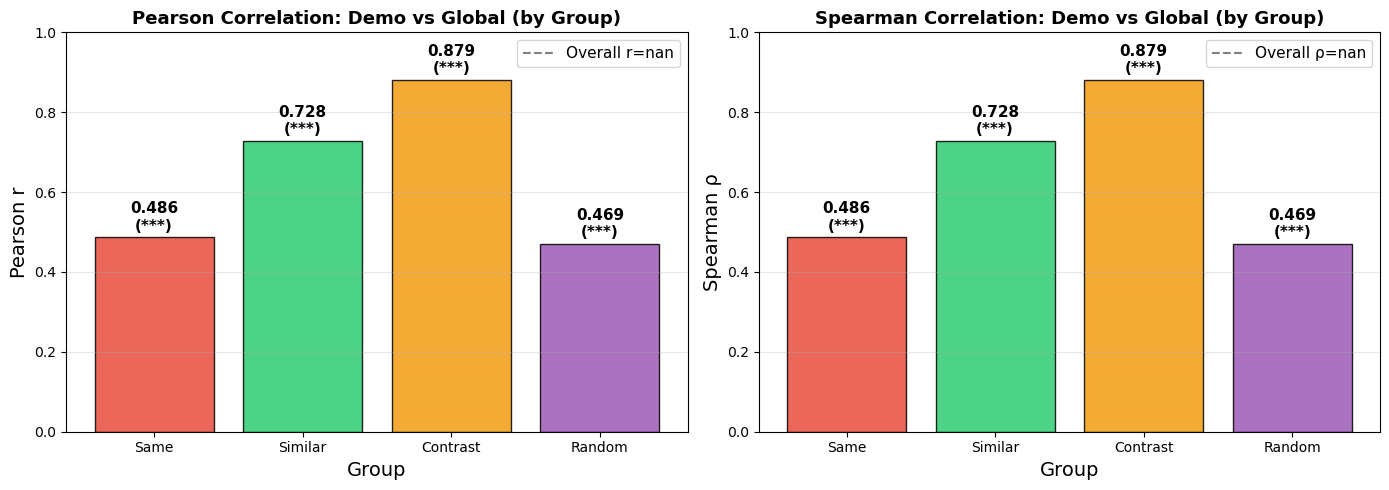

In [ ]:

# Calculate correlations between good_choice_demo and good_choice_global by group
from scipy.stats import pearsonr, spearmanr

print("="*70)
print("Correlation: good_choice_demo vs good_choice_global (by group)")
print("="*70)

corr_rows = []
for group in group_names:
    df_g = choices_results[choices_results['group_label'] == group]
    demo = df_g['good_choice_demo']
    glob = df_g['good_choice_global']
    pr, pp = pearsonr(demo, glob)
    sr, sp = spearmanr(demo, glob)
    corr_rows.append({'Group': group, 'Pearson_r': round(pr, 4), 'Pearson_p': round(pp, 4),
                      'Spearman_r': round(sr, 4), 'Spearman_p': round(sp, 4), 'N': len(df_g)})

# Overall
demo_all = choices_results['good_choice_demo']
glob_all = choices_results['good_choice_global']
pr, pp = pearsonr(demo_all, glob_all)
sr, sp = spearmanr(demo_all, glob_all)
corr_rows.append({'Group': 'Overall', 'Pearson_r': round(pr, 4), 'Pearson_p': round(pp, 4),
                  'Spearman_r': round(sr, 4), 'Spearman_p': round(sp, 4), 'N': len(choices_results)})

corr_df = pd.DataFrame(corr_rows)
print(corr_df.to_string(index=False))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of Pearson correlations by group
groups_only = corr_df[corr_df['Group'] != 'Overall']
bars = axes[0].bar(groups_only['Group'], groups_only['Pearson_r'],
                   color=colors_palette[:len(groups_only)], edgecolor='black', alpha=0.85)
for bar, p_val in zip(bars, groups_only['Pearson_p']):
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}\n({sig})', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Pearson r', fontsize=14)
axes[0].set_xlabel('Group', fontsize=14)
axes[0].set_title('Pearson Correlation: Demo vs Global (by Group)', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, min(1.0, groups_only['Pearson_r'].max() + 0.15))
axes[0].axhline(y=corr_df[corr_df['Group']=='Overall']['Pearson_r'].values[0],
                color='gray', linestyle='--', linewidth=1.5, label=f"Overall r={pr:.3f}")
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Bar plot of Spearman correlations by group
bars2 = axes[1].bar(groups_only['Group'], groups_only['Spearman_r'],
                    color=colors_palette[:len(groups_only)], edgecolor='black', alpha=0.85)
for bar, p_val in zip(bars2, groups_only['Spearman_p']):
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}\n({sig})', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Spearman ρ', fontsize=14)
axes[1].set_xlabel('Group', fontsize=14)
axes[1].set_title('Spearman Correlation: Demo vs Global (by Group)', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, min(1.0, groups_only['Spearman_r'].max() + 0.15))
axes[1].axhline(y=corr_df[corr_df['Group']=='Overall']['Spearman_r'].values[0],
                color='gray', linestyle='--', linewidth=1.5, label=f"Overall ρ={sr:.3f}")
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
